# mRI Wearable-Assisted Radar Knowledge Distillation — Corrected Kaggle P100 Pilot

**Primary research question:** Can a radar-only rehabilitation-exercise classifier improve when trained with supervision from a stronger radar–IMU teacher, while preserving radar-only inference?

This corrected notebook includes:

1. Automatic discovery of the **already extracted** Kaggle dataset.
2. Robust matching of radar, IMU, and pose-label files by subject.
3. An all-interval parser for `video_label` that does not stop after the first nested entry.
4. Strict manifest integrity checks before training.
5. A class-coverage-aware, subject-independent train/validation/test split.
6. Radar-only 2D-CNN + TCN baseline.
7. Radar–IMU gated-attention teacher.
8. Radar-only student with hard-label, logit, and feature distillation.
9. Accuracy, balanced accuracy, macro-F1, per-class F1, confusion matrices, and wearable-degradation tests.
10. Optional IMU-only, feature-fusion, and late-fusion baselines.

> The notebook uses proportional temporal transfer from annotation coordinates to radar and IMU feature lengths. This is appropriate for an initial feasibility study. For a final paper, exact timestamp-based alignment should be implemented after verifying the release metadata.

## Kaggle setup

1. Select **GPU P100** in the Kaggle notebook settings.
2. Add the private Kaggle dataset shown in your screenshot.
3. The notebook expects an extracted hierarchy similar to:

```text
/kaggle/input/dataset-mri/
└── dataset_release/
    └── dataset_release/
        ├── aligned_data/
        ├── features/
        ├── model/
        └── raw_data/
```

4. No Dryad download or ZIP extraction is required.
5. Run all cells in order.
6. Do not continue to model training unless the manifest audit shows many segments per class and multiple subjects per class.

In [25]:
from dataclasses import dataclass, asdict
from pathlib import Path

@dataclass
class CFG:
    DATA_ROOT: str | None = None
    WORK_DIR: str = "/kaggle/working/mri_kd_pilot"

    PROTOCOL: str = "P2_10"
    SEQ_LEN: int = 96
    MIN_SEGMENT_FRACTION: float = 0.001

    NUMERIC_LABEL_MODE: str = "auto"
    EXTRA_BACKGROUND_NUMERIC_IDS: tuple = (-1,)
    MIN_TOTAL_MANIFEST_SEGMENTS: int = 50
    MIN_SUBJECTS_PER_CLASS: int = 3

    TEST_SUBJECT_FRACTION: float = 0.20
    VAL_SUBJECT_FRACTION_OF_REMAINDER: float = 0.25
    SPLIT_SEED: int = 2026
    SPLIT_SEARCH_ATTEMPTS: int = 50000

    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 2
    CACHE_SUBJECTS_PER_WORKER: int = 3
    USE_WEIGHTED_SAMPLER: bool = False
    MAX_SEGMENTS_PER_CLASS_PER_SUBJECT: int | None = None

    EMBED_DIM: int = 128
    TCN_CHANNELS: tuple = (128, 128, 128, 128)
    TCN_DILATIONS: tuple = (1, 2, 4, 8)
    DROPOUT: float = 0.25

    RADAR_EPOCHS: int = 8
    TEACHER_EPOCHS: int = 10
    STUDENT_EPOCHS: int = 12
    EXTENDED_EPOCHS: int = 8
    LEARNING_RATE: float = 3e-4
    WEIGHT_DECAY: float = 1e-4
    PATIENCE: int = 4
    GRAD_CLIP: float = 5.0

    KD_TEMPERATURE: float = 4.0
    KD_ALPHA: float = 0.60
    FEATURE_BETA: float = 0.05
    FEATURE_LOSS: str = "cosine"

    AMP: bool = True
    RUN_EXTENDED_BASELINES: bool = True
    RUN_ROBUSTNESS: bool = True
    QUICK_RUN: bool = False
    SEED: int = 2026
    STAT_MAX_FRAMES_PER_SUBJECT: int = 4000

cfg = CFG()

if cfg.QUICK_RUN:
    cfg.RADAR_EPOCHS = 2
    cfg.TEACHER_EPOCHS = 2
    cfg.STUDENT_EPOCHS = 2
    cfg.EXTENDED_EPOCHS = 2

Path(cfg.WORK_DIR).mkdir(parents=True, exist_ok=True)
print(asdict(cfg))

{'DATA_ROOT': None, 'WORK_DIR': '/kaggle/working/mri_kd_pilot', 'PROTOCOL': 'P2_10', 'SEQ_LEN': 96, 'MIN_SEGMENT_FRACTION': 0.001, 'NUMERIC_LABEL_MODE': 'auto', 'EXTRA_BACKGROUND_NUMERIC_IDS': (-1,), 'MIN_TOTAL_MANIFEST_SEGMENTS': 50, 'MIN_SUBJECTS_PER_CLASS': 3, 'TEST_SUBJECT_FRACTION': 0.2, 'VAL_SUBJECT_FRACTION_OF_REMAINDER': 0.25, 'SPLIT_SEED': 2026, 'SPLIT_SEARCH_ATTEMPTS': 50000, 'BATCH_SIZE': 32, 'NUM_WORKERS': 2, 'CACHE_SUBJECTS_PER_WORKER': 3, 'USE_WEIGHTED_SAMPLER': False, 'MAX_SEGMENTS_PER_CLASS_PER_SUBJECT': None, 'EMBED_DIM': 128, 'TCN_CHANNELS': (128, 128, 128, 128), 'TCN_DILATIONS': (1, 2, 4, 8), 'DROPOUT': 0.25, 'RADAR_EPOCHS': 8, 'TEACHER_EPOCHS': 10, 'STUDENT_EPOCHS': 12, 'EXTENDED_EPOCHS': 8, 'LEARNING_RATE': 0.0003, 'WEIGHT_DECAY': 0.0001, 'PATIENCE': 4, 'GRAD_CLIP': 5.0, 'KD_TEMPERATURE': 4.0, 'KD_ALPHA': 0.6, 'FEATURE_BETA': 0.05, 'FEATURE_LOSS': 'cosine', 'AMP': True, 'RUN_EXTENDED_BASELINES': True, 'RUN_ROBUSTNESS': True, 'QUICK_RUN': False, 'SEED': 2026, 'STAT_

In [2]:
import os
import gc
import re
import json
import copy
import pickle
import random
import shutil
import zipfile
import warnings
from collections import Counter, defaultdict, OrderedDict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore", category=UserWarning)

def seed_everything(seed=2026):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"GPU memory: {props.total_memory / 1024**3:.1f} GB")
    if "P100" not in torch.cuda.get_device_name(0):
        print("Warning: designed for a Kaggle Tesla P100, but another CUDA GPU is active.")
else:
    print("Warning: enable Kaggle GPU P100 before training.")

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla P100-PCIE-16GB
GPU memory: 15.9 GB


In [3]:
from pathlib import Path

def looks_like_mri_root(path: Path) -> bool:
    return (
        path.exists()
        and path.is_dir()
        and (path / "features" / "radar").exists()
        and (path / "features" / "imu").exists()
        and (path / "aligned_data").exists()
        and (path / "raw_data").exists()
    )

def discover_mri_root(search_roots=None) -> Path | None:
    if cfg.DATA_ROOT is not None:
        configured = Path(cfg.DATA_ROOT)
        if looks_like_mri_root(configured):
            print("Using configured DATA_ROOT:", configured)
            return configured
        raise FileNotFoundError(
            f"Configured DATA_ROOT is not valid: {configured}\n"
            "It must directly contain features/, aligned_data/, and raw_data/."
        )

    exact_candidates = [
        Path("/kaggle/input/dataset-mri/dataset_release/dataset_release"),
        Path("/kaggle/input/dataset-mri/dataset_release"),
        Path("/kaggle/input/dataset-mri"),
    ]

    for candidate in exact_candidates:
        if looks_like_mri_root(candidate):
            print("Found mRI root:", candidate)
            return candidate

    search_roots = search_roots or [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
    ]

    for base in search_roots:
        if not base.exists():
            continue
        for features_dir in base.rglob("features"):
            candidate = features_dir.parent
            if looks_like_mri_root(candidate):
                print("Automatically discovered mRI root:", candidate)
                return candidate

    return None

DATA_ROOT = discover_mri_root()

if DATA_ROOT is None:
    print("Could not locate the mRI root. Shallow Kaggle input tree:")
    base = Path("/kaggle/input")
    if base.exists():
        for path in sorted(base.rglob("*")):
            try:
                rel = path.relative_to(base)
                if len(rel.parts) <= 5:
                    print("  " * (len(rel.parts) - 1) + rel.name + ("/" if path.is_dir() else ""))
            except Exception:
                pass

    raise FileNotFoundError(
        "The extracted mRI dataset could not be located. "
        "Set cfg.DATA_ROOT to the directory that directly contains "
        "aligned_data/, features/, model/, and raw_data/."
    )

RADAR_DIR = DATA_ROOT / "features" / "radar"
IMU_DIR = DATA_ROOT / "features" / "imu"
POSE_LABEL_DIR = DATA_ROOT / "aligned_data" / "pose_labels"
RAW_VIDEO_LABEL_DIR = DATA_ROOT / "raw_data" / "videolabels"

print("\nDataset root:", DATA_ROOT)
print("Radar features:", RADAR_DIR)
print("IMU features:", IMU_DIR)
print("Pose labels:", POSE_LABEL_DIR)
print("Raw video labels:", RAW_VIDEO_LABEL_DIR)

Automatically discovered mRI root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release

Dataset root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release
Radar features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar
IMU features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu
Pose labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels
Raw video labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/raw_data/videolabels


In [4]:
P1_CLASS_NAMES = [
    "left upper-limb extension",
    "right upper-limb extension",
    "both upper-limb extension",
    "left front lunge",
    "right front lunge",
    "squat",
    "left side lunge",
    "right side lunge",
    "left limb extension",
    "right limb extension",
    "free-form stretching/relaxing",
    "walking",
]
P2_CLASS_NAMES = P1_CLASS_NAMES[:10]
CLASS_NAMES = P2_CLASS_NAMES if cfg.PROTOCOL == "P2_10" else P1_CLASS_NAMES
NUM_CLASSES = len(CLASS_NAMES)

def normalise_text(x):
    x = str(x).strip().lower().replace("_", " ").replace("-", " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

ALIASES = {
    "left upper limb extension": 0,
    "left upper limbs extension": 0,
    "right upper limb extension": 1,
    "right upper limbs extension": 1,
    "both upper limb extension": 2,
    "both upper limbs extension": 2,
    "left front lunge": 3,
    "left front lung": 3,
    "right front lunge": 4,
    "right front lung": 4,
    "squat": 5,
    "left side lunge": 6,
    "left side lung": 6,
    "right side lunge": 7,
    "right side lung": 7,
    "left limb extension": 8,
    "left lower limb extension": 8,
    "right limb extension": 9,
    "right lower limb extension": 9,
    "free form stretching relaxing": 10,
    "free form stretch relax": 10,
    "stretching relaxing": 10,
    "relaxing stretching": 10,
    "walking": 11,
    "walk": 11,
}
BACKGROUND_ALIASES = {
    "", "none", "nan", "background", "bg", "transition", "idle",
    "t pose", "tpose", "calibration", "unknown", "other"
}

print(f"Protocol: {cfg.PROTOCOL} | classes: {NUM_CLASSES}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:02d}: {name}")

Protocol: P2_10 | classes: 10
00: left upper-limb extension
01: right upper-limb extension
02: both upper-limb extension
03: left front lunge
04: right front lunge
05: squat
06: left side lunge
07: right side lunge
08: left limb extension
09: right limb extension


In [5]:
def safe_pickle_load(path):
    with open(path, "rb") as handle:
        return pickle.load(handle)

def load_any(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".npy":
        return np.load(path, mmap_mode="r")
    if suffix in {".pt", ".pth"}:
        return torch.load(path, map_location="cpu", weights_only=False)
    if suffix in {".cpl", ".pkl", ".pickle"}:
        return safe_pickle_load(path)
    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as handle:
            return json.load(handle)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".txt", ".tsv"}:
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return path.read_text(errors="ignore")

    raise ValueError(f"Unsupported file: {path}")

def summarise_object(obj, depth=0, max_depth=3):
    indent = "  " * depth
    if depth > max_depth:
        return f"{indent}..."

    if isinstance(obj, dict):
        lines = [f"{indent}dict(keys={list(obj.keys())[:30]})"]
        for key, value in list(obj.items())[:8]:
            lines.append(
                f"{indent}- {key!r}: "
                f"{summarise_object(value, depth + 1, max_depth)}"
            )
        return "\n".join(lines)

    if isinstance(obj, pd.DataFrame):
        return f"{indent}DataFrame(shape={obj.shape}, columns={list(obj.columns)})"

    if torch.is_tensor(obj):
        preview = obj.reshape(-1)[:5].detach().cpu().tolist() if obj.numel() else []
        return (
            f"{indent}Tensor(shape={tuple(obj.shape)}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, np.ndarray):
        preview = obj.reshape(-1)[:5].tolist() if obj.size else []
        return (
            f"{indent}ndarray(shape={obj.shape}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, (list, tuple)):
        first = summarise_object(obj[0], depth + 1, max_depth) if obj else "empty"
        return f"{indent}{type(obj).__name__}(len={len(obj)}, first=\n{first})"

    return f"{indent}{type(obj).__name__}: {str(obj)[:300]}"

def extract_subject_id(path) -> str:
    text = str(path).lower()

    patterns = [
        r"subject[\s_\-]*0*(\d+)",
        r"subj(?:ect)?[\s_\-]*0*(\d+)",
        r"participant[\s_\-]*0*(\d+)",
        r"(?:^|[/_\-])s0*(\d+)(?:[/_\-.]|$)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return f"subject{int(match.group(1)):02d}"

    numbers = re.findall(r"(?<!\d)(\d{1,2})(?!\d)", Path(path).stem)
    if numbers:
        return f"subject{int(numbers[-1]):02d}"

    return Path(path).parent.name.lower().replace(" ", "_")

def choose_subject_file_map(paths, modality_name):
    grouped = defaultdict(list)
    for path in paths:
        grouped[extract_subject_id(path)].append(Path(path))

    selected = {}
    for subject, candidates in sorted(grouped.items()):
        candidates = sorted(candidates, key=lambda p: (len(str(p)), str(p)))
        selected[subject] = candidates[0]
        if len(candidates) > 1:
            print(
                f"Warning: {modality_name} has {len(candidates)} files for {subject}; "
                f"using {candidates[0]}"
            )
    return selected

def collect_files():
    radar_files = sorted(RADAR_DIR.rglob("*featuremap.npy"))
    if not radar_files:
        radar_files = sorted(RADAR_DIR.rglob("*.npy"))

    imu_files = sorted(IMU_DIR.rglob("acc_ori.pt"))
    if not imu_files:
        imu_files = sorted(IMU_DIR.rglob("*.pt"))

    pose_label_files = []
    if POSE_LABEL_DIR.exists():
        for extension in ("*.cpl", "*.pkl", "*.pickle", "*.json", "*.npy"):
            pose_label_files.extend(POSE_LABEL_DIR.rglob(extension))

    raw_label_files = []
    if RAW_VIDEO_LABEL_DIR.exists():
        for extension in (
            "*.csv", "*.txt", "*.tsv", "*.json",
            "*.npy", "*.cpl", "*.pkl", "*.pickle"
        ):
            raw_label_files.extend(RAW_VIDEO_LABEL_DIR.rglob(extension))

    return (
        sorted(set(radar_files)),
        sorted(set(imu_files)),
        sorted(set(pose_label_files)),
        sorted(set(raw_label_files)),
    )

radar_files, imu_files, pose_label_files, raw_label_files = collect_files()

radar_by_subject = choose_subject_file_map(radar_files, "radar")
imu_by_subject = choose_subject_file_map(imu_files, "IMU")
pose_label_by_subject = choose_subject_file_map(pose_label_files, "pose-label")
raw_label_by_subject = choose_subject_file_map(raw_label_files, "raw-label")

label_by_subject = dict(raw_label_by_subject)
label_by_subject.update(pose_label_by_subject)

common_subjects = sorted(
    set(radar_by_subject)
    & set(imu_by_subject)
    & set(label_by_subject)
)

print("Radar files:", len(radar_files))
print("IMU files:", len(imu_files))
print("Pose-label files:", len(pose_label_files))
print("Raw video-label files:", len(raw_label_files))
print("Matched subjects:", len(common_subjects))
print(common_subjects)

if not common_subjects:
    print("Radar subject keys:", sorted(radar_by_subject))
    print("IMU subject keys:", sorted(imu_by_subject))
    print("Label subject keys:", sorted(label_by_subject))
    raise RuntimeError(
        "No subjects matched across radar, IMU, and labels. "
        "Inspect filenames and update extract_subject_id()."
    )

sample_subject = common_subjects[0]
sample_radar = load_any(radar_by_subject[sample_subject])
sample_imu = load_any(imu_by_subject[sample_subject])
sample_label_obj = load_any(label_by_subject[sample_subject])

print("\nSample subject:", sample_subject)
print("Radar file:", radar_by_subject[sample_subject])
print("IMU file:", imu_by_subject[sample_subject])
print("Label file:", label_by_subject[sample_subject])
print("\nRadar object:\n", summarise_object(sample_radar))
print("\nIMU object:\n", summarise_object(sample_imu))
print("\nLabel object:\n", summarise_object(sample_label_obj))

Radar files: 20
IMU files: 20
Pose-label files: 20
Raw video-label files: 20
Matched subjects: 20
['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject09', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 'subject15', 'subject16', 'subject17', 'subject18', 'subject19', 'subject20']

Sample subject: subject01
Radar file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar/subject1_featuremap.npy
IMU file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu/subject1/acc_ori.pt
Label file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels/subject1_all_labels.cpl

Radar object:
 ndarray(shape=(6384, 14, 14, 5), dtype=float64, preview=[-0.86035, 2.582, 0.41699, 0.0, -0.6087622791159407])

IMU object:
 Tensor(shape=(6384, 6, 12), dtype=torch.float32, preview=[-0.010256187

## Annotation-coordinate correction

The release includes action boundaries expressed as timestamps. When those are
absolute wall/Unix timestamps, they must first be shifted to recording-relative
coordinates. Otherwise, a 30–60 second action divided by a timestamp near
`1.6e9` or `1.6e12` appears to have almost zero duration and is rejected.

The parser now detects this condition, subtracts the first annotation timestamp,
and prints the resulting duration-fraction audit.

In [6]:
START_NAMES = {
    "start", "begin", "onset", "start frame", "start time",
    "startframe", "starttime", "start index", "start idx"
}
END_NAMES = {
    "end", "stop", "offset", "end frame", "end time",
    "endframe", "endtime", "end index", "end idx"
}
LABEL_NAMES = {
    "label", "action", "activity", "class", "name", "value",
    "action label", "activity label", "class label"
}

def labels_equal(left, right):
    try:
        if pd.isna(left) and pd.isna(right):
            return True
    except Exception:
        pass
    try:
        return bool(left == right)
    except Exception:
        return False

def is_number(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return not pd.isna(value)
    if isinstance(value, str):
        try:
            float(value.strip())
            return True
        except Exception:
            return False
    return False

def is_scalar_label(value):
    return isinstance(
        value,
        (str, int, float, np.integer, np.floating, bool, np.bool_)
    )

def get_video_label_object(label_object):
    if isinstance(label_object, dict):
        for key, value in label_object.items():
            if normalise_text(key) in {
                "video label", "video labels", "videolabel",
                "action label", "action labels", "activity labels"
            }:
                return value
    return label_object

def finalise_segment_scale(segments, explicit_scale=None):
    """
    Clean, deduplicate, and convert interval coordinates to a proportional
    recording-relative system.

    Important:
    mRI annotations may use absolute wall/Unix timestamps. Dividing an action
    duration directly by a Unix timestamp makes every action fraction nearly
    zero. When coordinates look absolute, this function subtracts the first
    annotation timestamp before calculating the scale.
    """
    clean = []

    for segment in segments:
        try:
            start = float(segment["start"])
            end = float(segment["end"])
        except Exception:
            continue

        if not np.isfinite(start) or not np.isfinite(end) or end <= start:
            continue

        clean.append({
            "raw_label": segment["raw_label"],
            "start": start,
            "end": end,
            "scale": segment.get("scale"),
            "source": segment.get("source", "unknown"),
        })

    if not clean:
        return []

    minimum_start = min(item["start"] for item in clean)
    maximum_end = max(item["end"] for item in clean)

    if explicit_scale is not None:
        try:
            explicit_scale = float(explicit_scale)
            if np.isfinite(explicit_scale):
                maximum_end = max(maximum_end, explicit_scale)
        except Exception:
            pass

    raw_span = max(maximum_end - minimum_start, 1e-9)
    absolute_reference = max(abs(maximum_end), 1.0)
    relative_span_ratio = raw_span / absolute_reference

    # Detect wall/Unix-like coordinates. Examples:
    # seconds:      ~1.6e9
    # milliseconds: ~1.6e12
    # microseconds: ~1.6e15
    #
    # A large coordinate with a duration that is tiny relative to the
    # coordinate magnitude is almost certainly an absolute timestamp.
    absolute_like = (
        abs(minimum_start) >= 1e6
        and relative_span_ratio < 0.25
    ) or (
        abs(minimum_start) > 1000.0 * raw_span
    )

    origin = minimum_start if absolute_like else 0.0
    scale = maximum_end - origin

    if scale <= 0 or not np.isfinite(scale):
        raise ValueError(
            f"Invalid annotation scale after normalization: "
            f"origin={origin}, maximum_end={maximum_end}, scale={scale}"
        )

    normalised = []

    for item in clean:
        shifted_start = item["start"] - origin
        shifted_end = item["end"] - origin

        shifted_start = max(0.0, shifted_start)
        shifted_end = min(scale, shifted_end)

        if shifted_end <= shifted_start:
            continue

        normalised.append({
            "raw_label": item["raw_label"],
            "start": shifted_start,
            "end": shifted_end,
            "scale": scale,
            "source": item["source"],
            "coordinate_origin": origin,
            "absolute_timestamp_detected": absolute_like,
        })

    deduplicated = {}

    for item in normalised:
        key = (
            str(item["raw_label"]),
            round(item["start"], 8),
            round(item["end"], 8),
        )
        deduplicated[key] = item

    output = sorted(
        deduplicated.values(),
        key=lambda item: (
            item["start"],
            item["end"],
            str(item["raw_label"]),
        ),
    )

    if output:
        durations = [
            (item["end"] - item["start"]) / item["scale"]
            for item in output
        ]

        print(
            "Annotation coordinate audit:",
            {
                "intervals": len(output),
                "absolute_timestamp_detected": absolute_like,
                "origin": origin,
                "scale": scale,
                "minimum_duration_fraction": float(min(durations)),
                "median_duration_fraction": float(np.median(durations)),
                "maximum_duration_fraction": float(max(durations)),
            },
        )

    return output


def framewise_labels_to_segments(labels, positions=None, source="framewise"):
    labels = list(labels)
    if not labels:
        return []

    if positions is None:
        positions = np.arange(len(labels), dtype=np.float64)
    else:
        positions = np.asarray(positions, dtype=np.float64)

    if len(positions) != len(labels):
        raise ValueError(
            f"Positions length {len(positions)} != labels length {len(labels)}"
        )

    order = np.argsort(positions)
    positions = positions[order]
    labels = [labels[index] for index in order]

    if len(positions) > 1:
        steps = np.diff(positions)
        steps = steps[steps > 0]
        step = float(np.median(steps)) if len(steps) else 1.0
    else:
        step = 1.0

    total_scale = float(positions[-1] + step)
    segments = []
    run_start = 0
    current = labels[0]

    for index in range(1, len(labels)):
        if not labels_equal(labels[index], current):
            segments.append({
                "raw_label": current,
                "start": float(positions[run_start]),
                "end": float(positions[index]),
                "scale": total_scale,
                "source": source,
            })
            run_start = index
            current = labels[index]

    segments.append({
        "raw_label": current,
        "start": float(positions[run_start]),
        "end": total_scale,
        "scale": total_scale,
        "source": source,
    })

    return finalise_segment_scale(segments, explicit_scale=total_scale)

def find_named_key(mapping, candidate_names):
    normalised = {normalise_text(key): key for key in mapping.keys()}
    return next(
        (
            original
            for cleaned, original in normalised.items()
            if cleaned in candidate_names
        ),
        None,
    )

def parse_interval_record(record, inherited_label=None, source="interval_record"):
    if not isinstance(record, dict):
        return None

    start_key = find_named_key(record, START_NAMES)
    end_key = find_named_key(record, END_NAMES)
    label_key = find_named_key(record, LABEL_NAMES)

    if start_key is None or end_key is None:
        return None

    label = record[label_key] if label_key is not None else inherited_label
    if label is None:
        return None

    try:
        start = float(record[start_key])
        end = float(record[end_key])
    except Exception:
        return None

    if end <= start:
        return None

    return {
        "raw_label": label,
        "start": start,
        "end": end,
        "scale": None,
        "source": source,
    }

def interval_pairs_for_label(raw_label, value, source="label_intervals"):
    segments = []

    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()

    if isinstance(value, dict):
        start_key = find_named_key(value, START_NAMES)
        end_key = find_named_key(value, END_NAMES)

        if start_key is not None and end_key is not None:
            starts = value[start_key]
            ends = value[end_key]

            starts = [starts] if np.isscalar(starts) else list(starts)
            ends = [ends] if np.isscalar(ends) else list(ends)

            for start, end in zip(starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": raw_label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": source,
                    })
            return segments

        for nested in value.values():
            segments.extend(interval_pairs_for_label(raw_label, nested, source))
        return segments

    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=object)

        if (
            array.ndim == 1
            and len(array) >= 2
            and is_number(array[0])
            and is_number(array[1])
        ):
            start, end = float(array[0]), float(array[1])
            if end > start:
                segments.append({
                    "raw_label": raw_label,
                    "start": start,
                    "end": end,
                    "scale": None,
                    "source": source,
                })
            return segments

        if array.ndim == 2 and array.shape[1] >= 2:
            for row in array:
                if is_number(row[0]) and is_number(row[1]):
                    start, end = float(row[0]), float(row[1])
                    if end > start:
                        segments.append({
                            "raw_label": raw_label,
                            "start": start,
                            "end": end,
                            "scale": None,
                            "source": source,
                        })
            return segments

        for nested in list(value):
            segments.extend(interval_pairs_for_label(raw_label, nested, source))

    return segments

def parse_interval_matrix(array, source="interval_matrix"):
    array = np.asarray(array, dtype=object)
    if array.ndim != 2 or array.shape[1] < 3:
        return []

    layouts = [(0, 1, 2), (2, 0, 1)]
    candidates = []

    for label_col, start_col, end_col in layouts:
        parsed = []
        for row in array:
            if (
                is_number(row[start_col])
                and is_number(row[end_col])
                and float(row[end_col]) > float(row[start_col])
            ):
                parsed.append({
                    "raw_label": row[label_col],
                    "start": float(row[start_col]),
                    "end": float(row[end_col]),
                    "scale": None,
                    "source": source,
                })

        unique_labels = len({str(item["raw_label"]) for item in parsed})
        score = len(parsed) + (10 if 1 <= unique_labels <= 20 else 0)
        candidates.append((score, parsed))

    return max(candidates, key=lambda item: item[0])[1] if candidates else []

def extract_video_label_segments(label_object):
    video_label = get_video_label_object(label_object)

    if torch.is_tensor(video_label):
        video_label = video_label.detach().cpu().numpy()

    if isinstance(video_label, pd.DataFrame):
        records = []
        for row in video_label.to_dict("records"):
            parsed = parse_interval_record(row, source="dataframe_interval")
            if parsed is not None:
                records.append(parsed)
        if records:
            return finalise_segment_scale(records)

        if video_label.shape[1] == 1:
            return framewise_labels_to_segments(
                video_label.iloc[:, 0].tolist(),
                source="dataframe_framewise",
            )

        video_label = video_label.to_numpy(dtype=object)

    if isinstance(video_label, dict):
        label_key = find_named_key(video_label, LABEL_NAMES)
        start_key = find_named_key(video_label, START_NAMES)
        end_key = find_named_key(video_label, END_NAMES)

        if label_key is not None and start_key is not None and end_key is not None:
            labels = video_label[label_key]
            starts = video_label[start_key]
            ends = video_label[end_key]
            segments = []
            for label, start, end in zip(labels, starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": "parallel_arrays",
                    })
            if segments:
                return finalise_segment_scale(segments)

        if video_label and all(is_number(key) for key in video_label.keys()):
            if all(is_scalar_label(value) for value in video_label.values()):
                ordered = sorted(video_label.items(), key=lambda item: float(item[0]))
                return framewise_labels_to_segments(
                    labels=[value for _, value in ordered],
                    positions=[float(key) for key, _ in ordered],
                    source="dictionary_framewise",
                )

        interval_records = []
        for key, value in video_label.items():
            parsed = parse_interval_record(
                value,
                inherited_label=key,
                source="dictionary_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        labelled_intervals = []
        for raw_label, value in video_label.items():
            labelled_intervals.extend(
                interval_pairs_for_label(
                    raw_label,
                    value,
                    source="label_to_intervals",
                )
            )
        if labelled_intervals:
            return finalise_segment_scale(labelled_intervals)

        recursive_segments = []
        for value in video_label.values():
            if isinstance(value, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(value))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

        raise ValueError(
            "Unrecognised video_label dictionary schema. "
            f"Example keys: {list(video_label.keys())[:20]}"
        )

    if isinstance(video_label, (list, tuple)):
        if len(video_label) == 0:
            return []

        if all(is_scalar_label(value) for value in video_label):
            return framewise_labels_to_segments(
                video_label,
                source="list_framewise",
            )

        interval_records = []
        for item in video_label:
            parsed = parse_interval_record(
                item,
                source="list_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        array = np.asarray(video_label, dtype=object)
        parsed_matrix = parse_interval_matrix(array, source="list_interval_matrix")
        if parsed_matrix:
            return finalise_segment_scale(parsed_matrix)

        recursive_segments = []
        for item in video_label:
            if isinstance(item, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(item))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

    if isinstance(video_label, np.ndarray):
        if video_label.ndim == 0:
            return []

        if video_label.ndim == 1:
            return framewise_labels_to_segments(
                video_label.tolist(),
                source="array_framewise",
            )

        if video_label.ndim == 2:
            if 1 in video_label.shape:
                return framewise_labels_to_segments(
                    video_label.reshape(-1).tolist(),
                    source="array_framewise",
                )

            if video_label.shape[1] == 2:
                first_numeric = all(is_number(value) for value in video_label[:, 0])
                second_numeric = all(is_number(value) for value in video_label[:, 1])

                if first_numeric and not second_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 1].tolist(),
                        positions=[float(value) for value in video_label[:, 0]],
                        source="array_time_label",
                    )
                if second_numeric and not first_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 0].tolist(),
                        positions=[float(value) for value in video_label[:, 1]],
                        source="array_label_time",
                    )

            parsed = parse_interval_matrix(video_label, source="array_interval_matrix")
            if parsed:
                return finalise_segment_scale(parsed)

    raise ValueError(
        f"Unsupported video_label structure: {type(video_label)}"
    )

sample_segments = extract_video_label_segments(sample_label_obj)
print("Parsed sample intervals:", len(sample_segments))
display(pd.DataFrame(sample_segments).head(30))

if len(sample_segments) <= 1:
    print(
        "Warning: only one interval was parsed for the sample subject. "
        "Review the printed label-object schema before continuing."
    )

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
Parsed sample intervals: 13


,raw_label,start,end,scale,source,coordinate_origin,absolute_timestamp_detected
0,T pose,98.0,139.0,6481.0,label_to_intervals,0.0,False
1,pose_1,169.0,640.0,6481.0,label_to_intervals,0.0,False
2,pose_2,640.0,1122.0,6481.0,label_to_intervals,0.0,False
3,pose_3,1122.0,1661.0,6481.0,label_to_intervals,0.0,False
4,pose_4,1661.0,2173.0,6481.0,label_to_intervals,0.0,False
5,pose_5,2173.0,2692.0,6481.0,label_to_intervals,0.0,False
6,pose_6,2692.0,3206.0,6481.0,label_to_intervals,0.0,False
7,pose_7,3206.0,3723.0,6481.0,label_to_intervals,0.0,False
8,pose_8,3723.0,4253.0,6481.0,label_to_intervals,0.0,False
9,pose_9,4253.0,4744.0,6481.0,label_to_intervals,0.0,False


In [7]:
def maybe_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.strip())
        except Exception:
            return None
    return None

all_raw_segments = {}
parse_failures = {}
label_duration = defaultdict(float)
label_occurrences = Counter()

for subject in common_subjects:
    try:
        label_object = load_any(label_by_subject[subject])
        segments = extract_video_label_segments(label_object)
        all_raw_segments[subject] = segments

        for segment in segments:
            scale = float(segment.get("scale") or max(segment["end"], 1.0))
            duration = max(
                0.0,
                float(segment["end"]) - float(segment["start"])
            ) / max(scale, 1e-9)

            label_duration[segment["raw_label"]] += duration
            label_occurrences[segment["raw_label"]] += 1

        print(f"{subject}: {len(segments)} raw intervals")

    except Exception as error:
        parse_failures[subject] = repr(error)
        print(f"{subject}: PARSE FAILED -> {error}")

if parse_failures:
    print("\nParse failures:")
    for subject, error in parse_failures.items():
        print(subject, error)

total_raw_intervals = sum(len(items) for items in all_raw_segments.values())
print("\nTotal raw intervals:", total_raw_intervals)

raw_label_table = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": duration,
        "numeric_value": maybe_numeric(raw_label),
    }
    for raw_label, duration in label_duration.items()
]).sort_values(["numeric_value", "raw_label"], na_position="last")

display(raw_label_table)

numeric_values = sorted({
    int(value)
    for value in raw_label_table["numeric_value"].dropna().tolist()
    if float(value).is_integer()
})

NUMERIC_TO_CANONICAL = {}
BACKGROUND_NUMERIC = set(int(x) for x in cfg.EXTRA_BACKGROUND_NUMERIC_IDS)

def configure_numeric_mapping(mode, values):
    values = set(values)
    mapping = {}
    background = set(BACKGROUND_NUMERIC)

    if mode == "zero_background":
        background.add(0)
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "one_based":
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "direct":
        mapping = {value: value for value in range(12)}
    elif mode == "auto":
        if set(range(13)).issubset(values):
            background.add(0)
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(1, 13)).issubset(values):
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(12)).issubset(values):
            mapping = {value: value for value in range(12)}
        elif values and min(values) >= 1 and max(values) <= 12:
            mapping = {value: value - 1 for value in values}
        elif values and min(values) >= 0 and max(values) <= 11:
            mapping = {value: value for value in values}
        else:
            print(
                "Warning: numeric label scheme is ambiguous. "
                "Set cfg.NUMERIC_LABEL_MODE manually if mapping diagnostics look wrong."
            )
            non_background = sorted(value for value in values if value not in background)
            mapping = {
                value: index
                for index, value in enumerate(non_background[:12])
            }
    else:
        raise ValueError(
            "NUMERIC_LABEL_MODE must be auto, direct, one_based, or zero_background."
        )

    return mapping, background

NUMERIC_TO_CANONICAL, BACKGROUND_NUMERIC = configure_numeric_mapping(
    cfg.NUMERIC_LABEL_MODE,
    numeric_values,
)

print("Numeric values found:", numeric_values)
print("Numeric mapping:", NUMERIC_TO_CANONICAL)
print("Numeric background IDs:", sorted(BACKGROUND_NUMERIC))

def map_raw_label(raw_label):
    numeric = maybe_numeric(raw_label)

    if numeric is not None and float(numeric).is_integer():
        numeric = int(numeric)
        if numeric in BACKGROUND_NUMERIC:
            return None
        canonical = NUMERIC_TO_CANONICAL.get(numeric)
        if canonical is None or canonical >= NUM_CLASSES:
            return None
        return canonical

    text = normalise_text(raw_label)
    if text in BACKGROUND_ALIASES:
        return None

    canonical = ALIASES.get(text)

    if canonical is None:
        matches = {
            class_id
            for alias, class_id in ALIASES.items()
            if alias and (alias in text or text in alias)
        }
        canonical = next(iter(matches)) if len(matches) == 1 else None

    if canonical is None or canonical >= NUM_CLASSES:
        return None

    return canonical

mapping_diagnostic = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "mapped_class_id": map_raw_label(raw_label),
        "mapped_class_name": (
            CLASS_NAMES[map_raw_label(raw_label)]
            if map_raw_label(raw_label) is not None
            else "IGNORED"
        ),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": label_duration[raw_label],
    }
    for raw_label in label_duration.keys()
]).sort_values(["mapped_class_id", "raw_label"], na_position="last")

display(mapping_diagnostic)
mapping_diagnostic.to_csv(
    Path(cfg.WORK_DIR) / "label_mapping_diagnostic.csv",
    index=False,
)

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
subject01: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7193.0, 'minimum_duration_fraction': 0.005282913944112331, 'median_duration_fraction': 0.07562908383150285, 'maximum_duration_fraction': 0.10843875990546364}
subject02: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7039.0, 'minimum_duration_fraction': 0.0056826253729222904, 'median_duration_fraction': 0.07998295212388123, 'maximum_duration_fraction': 0.08992754652649525}
subject03: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6930.0

,raw_label,normalised,occurrences,duration_fraction,numeric_value
0,T pose,t pose,20,0.105875,None
13,T pose 2,t pose 2,13,0.036090,None
11,free_form,free form,20,1.639437,None
1,pose_1,pose 1,20,1.539689,None
10,pose_10,pose 10,20,1.585161,None
2,pose_2,pose 2,20,1.566915,None
3,pose_3,pose 3,20,1.569462,None
4,pose_4,pose 4,20,1.532832,None
5,pose_5,pose 5,20,1.586671,None
6,pose_6,pose 6,20,1.579234,None


Numeric values found: []
Numeric mapping: {}
Numeric background IDs: [-1]


,raw_label,normalised,mapped_class_id,mapped_class_name,occurrences,duration_fraction
0,T pose,t pose,None,IGNORED,20,0.105875
13,T pose 2,t pose 2,None,IGNORED,13,0.036090
11,free_form,free form,None,IGNORED,20,1.639437
1,pose_1,pose 1,None,IGNORED,20,1.539689
10,pose_10,pose 10,None,IGNORED,20,1.585161
2,pose_2,pose 2,None,IGNORED,20,1.566915
3,pose_3,pose 3,None,IGNORED,20,1.569462
4,pose_4,pose 4,None,IGNORED,20,1.532832
5,pose_5,pose 5,None,IGNORED,20,1.586671
6,pose_6,pose 6,None,IGNORED,20,1.579234


In [8]:
# ============================================================
# Build manifest with mRI-specific label mapping
# ============================================================

import re
from collections import Counter
from pathlib import Path

# ------------------------------------------------------------
# mRI label mapping
# ------------------------------------------------------------
#
# pose_1  -> left upper-limb extension
# pose_2  -> right upper-limb extension
# pose_3  -> both upper-limb extension
# pose_4  -> left front lunge
# pose_5  -> right front lunge
# pose_6  -> squat
# pose_7  -> left side lunge
# pose_8  -> right side lunge
# pose_9  -> left limb extension
# pose_10 -> right limb extension
#
# P1 additionally contains:
# free_form -> class 10
# walk      -> class 11
#
# T pose and T pose 2 are calibration/background intervals.


def normalise_mri_label(label):
    """
    Convert labels such as:
        pose_1    -> pose 1
        free_form -> free form
        T pose 2  -> t pose 2
    """
    text = str(label).strip().lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


BACKGROUND_MRI_LABELS = {
    "",
    "none",
    "nan",
    "background",
    "bg",
    "idle",
    "transition",
    "calibration",
    "t pose",
    "t pose 1",
    "t pose 2",
    "tpose",
    "tpose 1",
    "tpose 2",
}


def map_mri_label(raw_label):
    """
    Return:
        class_id, status

    status is one of:
        mapped
        background
        protocol_excluded
        unmapped
    """

    text = normalise_mri_label(raw_label)

    # --------------------------------------------------------
    # Calibration/background
    # --------------------------------------------------------
    if text in BACKGROUND_MRI_LABELS:
        return None, "background"

    # --------------------------------------------------------
    # pose_1 ... pose_10
    # --------------------------------------------------------
    pose_match = re.fullmatch(
        r"pose\s*0*(10|[1-9])",
        text,
    )

    if pose_match:
        pose_number = int(pose_match.group(1))
        class_id = pose_number - 1

        if 0 <= class_id < NUM_CLASSES:
            return class_id, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only free-form class
    # --------------------------------------------------------
    if text in {
        "free form",
        "freeform",
        "free form stretching",
        "free form stretching relaxing",
        "stretching relaxing",
    }:
        if NUM_CLASSES > 10:
            return 10, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only walking class
    # --------------------------------------------------------
    if text in {
        "walk",
        "walking",
        "straight line walk",
        "straight line walking",
    }:
        if NUM_CLASSES > 11:
            return 11, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # Fall back to the earlier descriptive-name mapper
    # --------------------------------------------------------
    existing_mapper = globals().get("map_raw_label")

    if callable(existing_mapper):
        try:
            mapped_id = existing_mapper(raw_label)

            if mapped_id is not None:
                mapped_id = int(mapped_id)

                if 0 <= mapped_id < NUM_CLASSES:
                    return mapped_id, "mapped"

                return None, "protocol_excluded"

        except Exception:
            pass

    return None, "unmapped"


# ------------------------------------------------------------
# Verify the mapping before building the manifest
# ------------------------------------------------------------

mapping_preview_labels = [
    "T pose",
    "pose_1",
    "pose_2",
    "pose_3",
    "pose_4",
    "pose_5",
    "pose_6",
    "pose_7",
    "pose_8",
    "pose_9",
    "pose_10",
    "free_form",
    "walk",
    "T pose 2",
]

mapping_preview = []

for raw_label in mapping_preview_labels:
    class_id, status = map_mri_label(raw_label)

    mapping_preview.append({
        "raw_label": raw_label,
        "normalised_label": normalise_mri_label(raw_label),
        "status": status,
        "class_id": class_id,
        "class_name": (
            CLASS_NAMES[class_id]
            if class_id is not None
            else None
        ),
    })

print("mRI label-mapping preview:")
display(pd.DataFrame(mapping_preview))


# ------------------------------------------------------------
# Build manifest
# ------------------------------------------------------------

manifest_rows = []

rejection_counts = Counter()
background_label_counts = Counter()
protocol_excluded_counts = Counter()
unmapped_label_counts = Counter()

short_segment_examples = []
valid_fraction_examples = []

for subject in common_subjects:
    segments = all_raw_segments.get(subject, [])

    rejection_counts["subjects_seen"] += 1
    rejection_counts["raw_segments_seen"] += len(segments)

    per_class_counter = Counter()

    for segment_index, segment in enumerate(segments):
        raw_label = segment.get("raw_label")

        class_id, label_status = map_mri_label(
            raw_label
        )

        # ----------------------------------------------------
        # Ignore calibration/background intervals
        # ----------------------------------------------------
        if label_status == "background":
            rejection_counts["background_or_calibration"] += 1
            background_label_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Ignore P1-only classes when running P2_10
        # ----------------------------------------------------
        if label_status == "protocol_excluded":
            rejection_counts["excluded_by_protocol"] += 1
            protocol_excluded_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Truly unknown label
        # ----------------------------------------------------
        if label_status == "unmapped":
            rejection_counts["unmapped_label"] += 1
            unmapped_label_counts[
                repr(raw_label)
            ] += 1
            continue

        if class_id is None:
            rejection_counts["unexpected_null_class"] += 1
            continue

        # ----------------------------------------------------
        # Read interval coordinates
        # ----------------------------------------------------
        try:
            start_value = float(
                segment["start"]
            )

            end_value = float(
                segment["end"]
            )

            scale = float(
                segment.get("scale")
                or max(end_value, 1.0)
            )

        except Exception:
            rejection_counts[
                "invalid_numeric_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(start_value)
            or not np.isfinite(end_value)
        ):
            rejection_counts[
                "non_finite_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(scale)
            or scale <= 0
        ):
            rejection_counts["invalid_scale"] += 1
            continue

        # ----------------------------------------------------
        # Convert to proportional recording coordinates
        # ----------------------------------------------------
        start_fraction = float(
            np.clip(
                start_value / scale,
                0.0,
                1.0,
            )
        )

        end_fraction = float(
            np.clip(
                end_value / scale,
                0.0,
                1.0,
            )
        )

        duration_fraction = (
            end_fraction
            - start_fraction
        )

        if end_fraction <= start_fraction:
            rejection_counts[
                "non_positive_interval"
            ] += 1
            continue

        # ----------------------------------------------------
        # Remove implausibly short segments
        # ----------------------------------------------------
        if (
            duration_fraction
            < cfg.MIN_SEGMENT_FRACTION
        ):
            rejection_counts[
                "below_minimum_fraction"
            ] += 1

            if len(short_segment_examples) < 20:
                short_segment_examples.append({
                    "subject": subject,
                    "raw_label": repr(raw_label),
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "start": start_value,
                    "end": end_value,
                    "scale": scale,
                    "duration_fraction": (
                        duration_fraction
                    ),
                    "absolute_timestamp_detected": (
                        segment.get(
                            "absolute_timestamp_detected"
                        )
                    ),
                    "coordinate_origin": (
                        segment.get(
                            "coordinate_origin"
                        )
                    ),
                })

            continue

        # ----------------------------------------------------
        # Optional per-subject/class limit
        # ----------------------------------------------------
        if (
            cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
            is not None
            and per_class_counter[class_id]
            >= cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
        ):
            rejection_counts[
                "class_subject_cap"
            ] += 1
            continue

        rejection_counts["accepted"] += 1

        if len(valid_fraction_examples) < 20:
            valid_fraction_examples.append({
                "subject": subject,
                "raw_label": repr(raw_label),
                "class_id": class_id,
                "class_name": (
                    CLASS_NAMES[class_id]
                ),
                "start_fraction": (
                    start_fraction
                ),
                "end_fraction": (
                    end_fraction
                ),
                "duration_fraction": (
                    duration_fraction
                ),
            })

        manifest_rows.append({
            "sample_id": (
                f"{subject}_"
                f"{segment_index:05d}"
            ),
            "subject": subject,
            "class_id": class_id,
            "class_name": (
                CLASS_NAMES[class_id]
            ),
            "start_frac": start_fraction,
            "end_frac": end_fraction,
            "duration_frac": (
                duration_fraction
            ),
            "source_start": start_value,
            "source_end": end_value,
            "source_scale": scale,
            "coordinate_origin": (
                segment.get(
                    "coordinate_origin",
                    0.0,
                )
            ),
            "absolute_timestamp_detected": (
                segment.get(
                    "absolute_timestamp_detected",
                    False,
                )
            ),
            "raw_label": str(raw_label),
            "normalised_raw_label": (
                normalise_mri_label(
                    raw_label
                )
            ),
            "label_source": (
                segment.get(
                    "source",
                    "unknown",
                )
            ),
            "radar_path": str(
                radar_by_subject[subject]
            ),
            "imu_path": str(
                imu_by_subject[subject]
            ),
            "label_path": str(
                label_by_subject[subject]
            ),
        })

        per_class_counter[
            class_id
        ] += 1


# ------------------------------------------------------------
# Manifest-construction audit
# ------------------------------------------------------------

print("\nManifest construction audit:")

rejection_table = pd.DataFrame(
    sorted(
        rejection_counts.items()
    ),
    columns=[
        "stage",
        "count",
    ],
)

display(rejection_table)


if background_label_counts:
    print(
        "\nIgnored calibration/background labels:"
    )

    display(
        pd.DataFrame(
            background_label_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if protocol_excluded_counts:
    print(
        "\nLabels excluded by the selected protocol:"
    )

    display(
        pd.DataFrame(
            protocol_excluded_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if unmapped_label_counts:
    print(
        "\nUnrecognised labels that still require mapping:"
    )

    display(
        pd.DataFrame(
            unmapped_label_counts.most_common(30),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if short_segment_examples:
    print(
        "\nExamples rejected as too short:"
    )

    display(
        pd.DataFrame(
            short_segment_examples
        )
    )


if valid_fraction_examples:
    print(
        "\nExamples accepted into the manifest:"
    )

    display(
        pd.DataFrame(
            valid_fraction_examples
        )
    )


# ------------------------------------------------------------
# Construct DataFrame
# ------------------------------------------------------------

manifest = pd.DataFrame(
    manifest_rows
)


if manifest.empty:
    raise RuntimeError(
        "No usable action segments were created. "
        "Review the manifest audit above. "
        "The mRI pose labels are now mapped explicitly, "
        "so any remaining failure is likely caused by "
        "interval coordinates or filtering."
    )


# ------------------------------------------------------------
# Complete-manifest statistics
# ------------------------------------------------------------

class_counts_complete = (
    manifest["class_id"]
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


class_subject_counts = (
    manifest
    .groupby("class_id")["subject"]
    .nunique()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


complete_audit = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "segments": (
        class_counts_complete.values
    ),
    "subjects": (
        class_subject_counts.values
    ),
})


print(
    "\nTotal manifest segments:",
    len(manifest),
)

print(
    "Manifest subjects:",
    manifest["subject"].nunique(),
)

display(
    complete_audit
)


subject_class_table = pd.crosstab(
    manifest["subject"],
    manifest["class_id"],
).reindex(
    columns=range(NUM_CLASSES),
    fill_value=0,
)


subject_class_table.columns = [
    (
        f"{class_id}: "
        f"{CLASS_NAMES[class_id]}"
    )
    for class_id
    in subject_class_table.columns
]


display(
    subject_class_table
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

missing_classes = (
    class_counts_complete[
        class_counts_complete == 0
    ]
    .index
    .tolist()
)


insufficient_subject_classes = (
    class_subject_counts[
        class_subject_counts
        < cfg.MIN_SUBJECTS_PER_CLASS
    ]
    .index
    .tolist()
)


if missing_classes:
    missing_details = {
        class_id: CLASS_NAMES[class_id]
        for class_id in missing_classes
    }

    raise RuntimeError(
        "The complete manifest is missing classes: "
        f"{missing_details}."
    )


if (
    len(manifest)
    < cfg.MIN_TOTAL_MANIFEST_SEGMENTS
):
    raise RuntimeError(
        f"Only {len(manifest)} manifest segments "
        "were extracted. "
        f"At least "
        f"{cfg.MIN_TOTAL_MANIFEST_SEGMENTS} "
        "are required."
    )


if insufficient_subject_classes:
    details = {
        class_id: {
            "class_name": CLASS_NAMES[
                class_id
            ],
            "subjects": int(
                class_subject_counts.loc[
                    class_id
                ]
            ),
        }
        for class_id
        in insufficient_subject_classes
    }

    raise RuntimeError(
        "Some classes occur in too few subjects "
        "for subject-independent evaluation: "
        f"{details}."
    )


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

manifest.to_csv(
    Path(cfg.WORK_DIR)
    / "full_manifest.csv",
    index=False,
)


subject_class_table.to_csv(
    Path(cfg.WORK_DIR)
    / "subject_class_distribution.csv"
)


complete_audit.to_csv(
    Path(cfg.WORK_DIR)
    / "complete_manifest_audit.csv",
    index=False,
)


print(
    "\nManifest integrity checks passed."
)

mRI label-mapping preview:


,raw_label,normalised_label,status,class_id,class_name
0,T pose,t pose,background,NaN,None
1,pose_1,pose 1,mapped,0.0,left upper-limb extension
2,pose_2,pose 2,mapped,1.0,right upper-limb extension
3,pose_3,pose 3,mapped,2.0,both upper-limb extension
4,pose_4,pose 4,mapped,3.0,left front lunge
5,pose_5,pose 5,mapped,4.0,right front lunge
6,pose_6,pose 6,mapped,5.0,squat
7,pose_7,pose 7,mapped,6.0,left side lunge
8,pose_8,pose 8,mapped,7.0,right side lunge
9,pose_9,pose 9,mapped,8.0,left limb extension



Manifest construction audit:


,stage,count
0,accepted,200
1,background_or_calibration,33
2,excluded_by_protocol,40
3,raw_segments_seen,273
4,subjects_seen,20



Ignored calibration/background labels:


...

,subject,raw_label,class_id,class_name,start_fraction,end_fraction,duration_fraction
0,subject01,'pose_1',0,left upper-limb extension,0.026076,0.098750,0.072674
1,subject01,'pose_2',1,right upper-limb extension,0.098750,0.173121,0.074371
2,subject01,'pose_3',2,both upper-limb extension,0.173121,0.256288,0.083166
3,subject01,'pose_4',3,left front lunge,0.256288,0.335288,0.079000
4,subject01,'pose_5',4,right front lunge,0.335288,0.415368,0.080080
5,subject01,'pose_6',5,squat,0.415368,0.494677,0.079309
6,subject01,'pose_7',6,left side lunge,0.494677,0.574448,0.079772
7,subject01,'pose_8',7,right side lunge,0.574448,0.656226,0.081778
8,subject01,'pose_9',8,left limb extension,0.656226,0.731986,0.075760
9,subject01,'pose_10',9,right limb extension,0.731986,0.818084,0.086098



Total manifest segments: 200
Manifest subjects: 20


,class_id,class_name,segments,subjects
0,0,left upper-limb extension,20,20
1,1,right upper-limb extension,20,20
2,2,both upper-limb extension,20,20
3,3,left front lunge,20,20
4,4,right front lunge,20,20
5,5,squat,20,20
6,6,left side lunge,20,20
7,7,right side lunge,20,20
8,8,left limb extension,20,20
9,9,right limb extension,20,20


,0: left upper-limb extension,1: right upper-limb extension,2: both upper-limb extension,3: left front lunge,4: right front lunge,5: squat,6: left side lunge,7: right side lunge,8: left limb extension,9: right limb extension
subject,,,,,,,,,,
subject01,1,1,1,1,1,1,1,1,1,1
subject02,1,1,1,1,1,1,1,1,1,1
subject03,1,1,1,1,1,1,1,1,1,1
subject04,1,1,1,1,1,1,1,1,1,1
subject05,1,1,1,1,1,1,1,1,1,1
subject06,1,1,1,1,1,1,1,1,1,1
subject07,1,1,1,1,1,1,1,1,1,1
subject08,1,1,1,1,1,1,1,1,1,1
subject09,1,1,1,1,1,1,1,1,1,1



Manifest integrity checks passed.


In [9]:
def unwrap_imu_tensor(obj):
    if isinstance(obj, dict):
        for key in ["acc_ori", "data", "features", "x", "imu"]:
            if key in obj and (
                torch.is_tensor(obj[key])
                or isinstance(obj[key], np.ndarray)
            ):
                obj = obj[key]
                break
        else:
            values = [
                value
                for value in obj.values()
                if torch.is_tensor(value) or isinstance(value, np.ndarray)
            ]
            if not values:
                raise TypeError("No tensor-like IMU value found.")
            obj = values[0]

    if torch.is_tensor(obj):
        obj = obj.detach().cpu().numpy()

    return np.asarray(obj)

def canonicalise_imu_shape(array):
    array = np.asarray(array)

    if array.ndim == 3 and array.shape[1:] == (6, 12):
        return array
    if array.ndim == 3 and array.shape[:2] == (6, 12):
        return np.moveaxis(array, -1, 0)
    if array.ndim == 2 and array.shape[1] == 72:
        return array.reshape(array.shape[0], 6, 12)
    if array.ndim == 2 and array.shape[0] == 72:
        return array.T.reshape(array.shape[1], 6, 12)

    raise ValueError(f"Unexpected IMU shape: {array.shape}")

def canonicalise_radar_shape(array):
    array = np.asarray(array)

    if array.ndim != 4:
        raise ValueError(f"Unexpected radar shape: {array.shape}")
    if array.shape[-1] == 5:
        return array
    if array.shape[1] == 5:
        return np.moveaxis(array, 1, -1)

    raise ValueError(
        f"Could not identify five radar channels in shape {array.shape}"
    )

audit_rows = []

for subject in common_subjects:
    radar = canonicalise_radar_shape(
        np.load(radar_by_subject[subject], mmap_mode="r")
    )
    imu = canonicalise_imu_shape(
        unwrap_imu_tensor(load_any(imu_by_subject[subject]))
    )

    audit_rows.append({
        "subject": subject,
        "radar_frames": int(radar.shape[0]),
        "radar_shape": str(tuple(radar.shape)),
        "imu_frames": int(imu.shape[0]),
        "imu_shape": str(tuple(imu.shape)),
        "manifest_segments": int(
            (manifest["subject"] == subject).sum()
        ),
        "manifest_classes": int(
            manifest.loc[
                manifest["subject"] == subject,
                "class_id"
            ].nunique()
        ),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_df.to_csv(
    Path(cfg.WORK_DIR) / "dataset_audit.csv",
    index=False,
)

if (audit_df["manifest_segments"] <= 1).any():
    print(
        "Warning: one or more subjects have at most one parsed action segment. "
        "Inspect those subjects before relying on the results."
    )

,subject,radar_frames,radar_shape,imu_frames,imu_shape,manifest_segments,manifest_classes
0,subject01,6384,"(6384, 14, 14, 5)",6384,"(6384, 6, 12)",10,10
1,subject02,7150,"(7150, 14, 14, 5)",7150,"(7150, 6, 12)",10,10
2,subject03,6982,"(6982, 14, 14, 5)",6982,"(6982, 6, 12)",10,10
3,subject04,6893,"(6893, 14, 14, 5)",6893,"(6893, 6, 12)",10,10
4,subject05,7219,"(7219, 14, 14, 5)",7219,"(7219, 6, 12)",10,10
5,subject06,6906,"(6906, 14, 14, 5)",6906,"(6906, 6, 12)",10,10
6,subject07,6743,"(6743, 14, 14, 5)",6743,"(6743, 6, 12)",10,10
7,subject08,6817,"(6817, 14, 14, 5)",6817,"(6817, 6, 12)",10,10
8,subject09,6704,"(6704, 14, 14, 5)",6704,"(6704, 6, 12)",10,10
9,subject10,6911,"(6911, 14, 14, 5)",6911,"(6911, 6, 12)",10,10


In [10]:
def counts_for_subjects(frame, selected_subjects):
    return (
        frame.loc[
            frame["subject"].isin(selected_subjects),
            "class_id"
        ]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

def find_coverage_aware_split(
    frame,
    seed,
    max_attempts,
    test_fraction,
    val_fraction_of_remainder,
):
    subjects = np.array(sorted(frame["subject"].unique()))
    number_of_subjects = len(subjects)

    if number_of_subjects < 5:
        raise RuntimeError(
            f"Only {number_of_subjects} subjects are available. "
            "At least five are required."
        )

    number_test = max(1, int(round(number_of_subjects * test_fraction)))
    number_remaining = number_of_subjects - number_test
    number_val = max(
        1,
        int(round(number_remaining * val_fraction_of_remainder))
    )
    number_train = number_of_subjects - number_test - number_val

    if number_train < 1:
        raise RuntimeError("The requested fractions leave no training subjects.")

    print(
        f"Searching for {number_train} train, {number_val} validation, "
        f"and {number_test} test subjects."
    )

    global_distribution = (
        frame["class_id"]
        .value_counts(normalize=True)
        .reindex(range(NUM_CLASSES), fill_value=0)
        .values
    )

    rng = np.random.default_rng(seed)
    best = None
    best_score = np.inf

    for attempt in range(max_attempts):
        shuffled = rng.permutation(subjects)

        test_subjects = shuffled[:number_test]
        val_subjects = shuffled[
            number_test:number_test + number_val
        ]
        train_subjects = shuffled[
            number_test + number_val:
        ]

        train_counts = counts_for_subjects(frame, train_subjects)
        val_counts = counts_for_subjects(frame, val_subjects)
        test_counts = counts_for_subjects(frame, test_subjects)

        missing_train = int((train_counts == 0).sum())
        missing_val = int((val_counts == 0).sum())
        missing_test = int((test_counts == 0).sum())

        def distribution_distance(counts):
            if counts.sum() == 0:
                return np.inf
            return float(
                np.abs(counts.values / counts.sum() - global_distribution).sum()
            )

        score = (
            1_000_000 * missing_train
            + 100_000 * missing_val
            + 100_000 * missing_test
            + distribution_distance(train_counts)
            + distribution_distance(val_counts)
            + distribution_distance(test_counts)
        )

        candidate = {
            "train_subjects": train_subjects,
            "val_subjects": val_subjects,
            "test_subjects": test_subjects,
            "train_counts": train_counts,
            "val_counts": val_counts,
            "test_counts": test_counts,
            "attempt": attempt + 1,
            "score": score,
        }

        if score < best_score:
            best_score = score
            best = candidate

        if missing_train == 0 and missing_val == 0 and missing_test == 0:
            print(f"Full-coverage split found after {attempt + 1} attempts.")
            return candidate

    raise RuntimeError(
        "No subject-independent split with complete class coverage was found "
        f"after {max_attempts} attempts. Best split had missing counts: "
        f"train={(best['train_counts'] == 0).sum()}, "
        f"validation={(best['val_counts'] == 0).sum()}, "
        f"test={(best['test_counts'] == 0).sum()}. "
        "Inspect subject_class_distribution.csv."
    )

split_result = find_coverage_aware_split(
    frame=manifest,
    seed=cfg.SPLIT_SEED,
    max_attempts=cfg.SPLIT_SEARCH_ATTEMPTS,
    test_fraction=cfg.TEST_SUBJECT_FRACTION,
    val_fraction_of_remainder=cfg.VAL_SUBJECT_FRACTION_OF_REMAINDER,
)

train_subjects = np.array(split_result["train_subjects"])
val_subjects = np.array(split_result["val_subjects"])
test_subjects = np.array(split_result["test_subjects"])

split_map = {subject: "train" for subject in train_subjects}
split_map.update({subject: "val" for subject in val_subjects})
split_map.update({subject: "test" for subject in test_subjects})

manifest["split"] = manifest["subject"].map(split_map)

train_df = manifest.loc[
    manifest["split"] == "train"
].reset_index(drop=True)

val_df = manifest.loc[
    manifest["split"] == "val"
].reset_index(drop=True)

test_df = manifest.loc[
    manifest["split"] == "test"
].reset_index(drop=True)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("\nTrain subjects:", sorted(train_subjects.tolist()))
print("Validation subjects:", sorted(val_subjects.tolist()))
print("Test subjects:", sorted(test_subjects.tolist()))
print(
    "Samples:",
    {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
    },
)

split_audit_rows = []

for split_name, split_frame in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    counts = (
        split_frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

    for class_id in range(NUM_CLASSES):
        split_audit_rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "segments": int(counts.loc[class_id]),
            "subjects": int(
                split_frame.loc[
                    split_frame["class_id"] == class_id,
                    "subject"
                ].nunique()
            ),
        })

split_audit = pd.DataFrame(split_audit_rows)
display(split_audit)

if (split_audit["segments"] == 0).any():
    raise RuntimeError(
        "A split is missing at least one class despite the coverage search."
    )

manifest.to_csv(
    Path(cfg.WORK_DIR) / "manifest_with_splits.csv",
    index=False,
)
split_audit.to_csv(
    Path(cfg.WORK_DIR) / "split_class_audit.csv",
    index=False,
)

Searching for 12 train, 4 validation, and 4 test subjects.
Full-coverage split found after 1 attempts.

Train subjects: ['subject03', 'subject04', 'subject05', 'subject06', 'subject08', 'subject09', 'subject11', 'subject12', 'subject13', 'subject17', 'subject18', 'subject20']
Validation subjects: ['subject02', 'subject07', 'subject14', 'subject16']
Test subjects: ['subject01', 'subject10', 'subject15', 'subject19']
Samples: {'train': 120, 'validation': 40, 'test': 40}


,split,class_id,class_name,segments,subjects
0,train,0,left upper-limb extension,12,12
1,train,1,right upper-limb extension,12,12
2,train,2,both upper-limb extension,12,12
3,train,3,left front lunge,12,12
4,train,4,right front lunge,12,12
5,train,5,squat,12,12
6,train,6,left side lunge,12,12
7,train,7,right side lunge,12,12
8,train,8,left limb extension,12,12
9,train,9,right limb extension,12,12


In [11]:
def compute_training_stats(subject_list):
    radar_sum = np.zeros(5, dtype=np.float64)
    radar_sumsq = np.zeros(5, dtype=np.float64)
    radar_count = 0

    imu_sum = np.zeros(72, dtype=np.float64)
    imu_sumsq = np.zeros(72, dtype=np.float64)
    imu_count = 0

    for subject in subject_list:
        radar = canonicalise_radar_shape(np.load(radar_by_subject[subject], mmap_mode="r"))
        n = radar.shape[0]
        if n > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx = np.linspace(0, n - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            radar_sample = np.asarray(radar[idx], dtype=np.float32)
        else:
            radar_sample = np.asarray(radar, dtype=np.float32)
        flat_r = radar_sample.reshape(-1, 5).astype(np.float64)
        radar_sum += flat_r.sum(axis=0)
        radar_sumsq += np.square(flat_r).sum(axis=0)
        radar_count += flat_r.shape[0]

        imu = canonicalise_imu_shape(unwrap_imu_tensor(load_any(imu_by_subject[subject])))
        n_i = imu.shape[0]
        if n_i > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx_i = np.linspace(0, n_i - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            imu_sample = imu[idx_i]
        else:
            imu_sample = imu
        flat_i = imu_sample.reshape(-1, 72).astype(np.float64)
        imu_sum += flat_i.sum(axis=0)
        imu_sumsq += np.square(flat_i).sum(axis=0)
        imu_count += flat_i.shape[0]

    radar_mean = radar_sum / radar_count
    radar_var = np.maximum(radar_sumsq / radar_count - radar_mean**2, 1e-8)
    imu_mean = imu_sum / imu_count
    imu_var = np.maximum(imu_sumsq / imu_count - imu_mean**2, 1e-8)

    return {
        "radar_mean": radar_mean.astype(np.float32),
        "radar_std": np.sqrt(radar_var).astype(np.float32),
        "imu_mean": imu_mean.astype(np.float32),
        "imu_std": np.sqrt(imu_var).astype(np.float32),
    }

stats = compute_training_stats(train_subjects)
print("Radar mean:", stats["radar_mean"])
print("Radar std:", stats["radar_std"])
np.savez(Path(cfg.WORK_DIR) / "normalisation_stats.npz", **stats)

Radar mean: [-3.9595038e-02  1.0351279e+00  4.3106000e-03 -1.7172944e-04
 -2.7271398e-04]
Radar std: [0.59321713 1.1836222  0.55033183 0.33115694 0.68407977]


In [12]:
def temporal_resample_np(array, target_length):
    array = np.asarray(array, dtype=np.float32)

    if array.shape[0] == target_length:
        return array
    if array.shape[0] < 2:
        return np.repeat(array, target_length, axis=0)

    flattened = torch.from_numpy(
        array.reshape(array.shape[0], -1).T
    ).unsqueeze(0)

    resized = F.interpolate(
        flattened,
        size=target_length,
        mode="linear",
        align_corners=False,
    )

    return (
        resized.squeeze(0)
        .T.numpy()
        .reshape((target_length,) + array.shape[1:])
    )

class MRISegmentDataset(Dataset):
    def __init__(self, frame, stats, sequence_length, cache_size=3):
        self.frame = frame.reset_index(drop=True).copy()
        self.sequence_length = sequence_length

        self.radar_mean = stats["radar_mean"].reshape(1, 1, 1, 5)
        self.radar_std = np.maximum(
            stats["radar_std"].reshape(1, 1, 1, 5),
            1e-6,
        )

        self.imu_mean = stats["imu_mean"].reshape(1, 72)
        self.imu_std = np.maximum(
            stats["imu_std"].reshape(1, 72),
            1e-6,
        )

        self.cache_size = cache_size
        self._cache = OrderedDict()

    def __len__(self):
        return len(self.frame)

    def _load_subject(self, radar_path, imu_path):
        key = (radar_path, imu_path)

        if key in self._cache:
            self._cache.move_to_end(key)
            return self._cache[key]

        radar = canonicalise_radar_shape(
            np.load(radar_path, mmap_mode="r")
        )

        imu = canonicalise_imu_shape(
            unwrap_imu_tensor(load_any(imu_path))
        )

        self._cache[key] = (radar, imu)
        self._cache.move_to_end(key)

        while len(self._cache) > self.cache_size:
            self._cache.popitem(last=False)

        return radar, imu

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        radar_full, imu_full = self._load_subject(
            row.radar_path,
            row.imu_path,
        )

        radar_start = int(round(row.start_frac * len(radar_full)))
        radar_end = int(round(row.end_frac * len(radar_full)))
        imu_start = int(round(row.start_frac * len(imu_full)))
        imu_end = int(round(row.end_frac * len(imu_full)))

        radar_start = min(max(radar_start, 0), len(radar_full) - 1)
        radar_end = min(max(radar_end, radar_start + 1), len(radar_full))
        imu_start = min(max(imu_start, 0), len(imu_full) - 1)
        imu_end = min(max(imu_end, imu_start + 1), len(imu_full))

        radar = np.asarray(
            radar_full[radar_start:radar_end],
            dtype=np.float32,
        )

        imu = np.asarray(
            imu_full[imu_start:imu_end],
            dtype=np.float32,
        ).reshape(-1, 72)

        if radar.shape[0] == 0 or imu.shape[0] == 0:
            raise RuntimeError(
                f"Empty modality slice for {row.sample_id}: "
                f"radar={radar.shape}, imu={imu.shape}"
            )

        radar = temporal_resample_np(
            radar,
            self.sequence_length,
        )

        imu = temporal_resample_np(
            imu,
            self.sequence_length,
        )

        radar = np.nan_to_num(
            (radar - self.radar_mean) / self.radar_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        imu = np.nan_to_num(
            (imu - self.imu_mean) / self.imu_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        return {
            "radar": torch.from_numpy(radar).float(),
            "imu": torch.from_numpy(imu).float(),
            "label": torch.tensor(
                int(row.class_id),
                dtype=torch.long,
            ),
            "subject": row.subject,
            "sample_id": row.sample_id,
        }

train_dataset = MRISegmentDataset(
    train_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

val_dataset = MRISegmentDataset(
    val_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

test_dataset = MRISegmentDataset(
    test_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

class_counts = (
    train_df["class_id"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

if (class_counts == 0).any():
    raise RuntimeError(
        "Training split is missing classes "
        f"{class_counts[class_counts == 0].index.tolist()}."
    )

class_weights_np = (
    len(train_df)
    / (NUM_CLASSES * class_counts.values.astype(np.float64))
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=DEVICE,
)

print(
    "Training class weights:",
    dict(zip(CLASS_NAMES, class_weights_np.round(3))),
)

sampler = None
shuffle = True

if cfg.USE_WEIGHTED_SAMPLER:
    weight_map = dict(zip(range(NUM_CLASSES), class_weights_np))
    sample_weights = train_df["class_id"].map(weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=len(sample_weights),
        replacement=True,
    )

    shuffle = False

pin_memory = DEVICE.type == "cuda"
persistent_workers = cfg.NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    sampler=sampler,
    shuffle=shuffle,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

batch = next(iter(train_loader))

print("Radar batch:", tuple(batch["radar"].shape))
print("IMU batch:", tuple(batch["imu"].shape))
print("Labels:", tuple(batch["label"].shape))
print("Label IDs in batch:", sorted(batch["label"].unique().tolist()))

Training class weights: {'left upper-limb extension': np.float64(1.0), 'right upper-limb extension': np.float64(1.0), 'both upper-limb extension': np.float64(1.0), 'left front lunge': np.float64(1.0), 'right front lunge': np.float64(1.0), 'squat': np.float64(1.0), 'left side lunge': np.float64(1.0), 'right side lunge': np.float64(1.0), 'left limb extension': np.float64(1.0), 'right limb extension': np.float64(1.0)}
Radar batch: (32, 96, 14, 14, 5)
IMU batch: (32, 96, 72)
Labels: (32,)
Label IDs in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Pre-training readiness rule

Proceed only when all of the following are true:

- The complete manifest contains every configured class.
- Each class occurs in at least three different subjects.
- The train, validation, and test splits each contain every class.
- The printed batch shapes are `(B, T, 14, 14, 5)` for radar and `(B, T, 72)` for IMU.

The notebook intentionally stops early when these conditions are not met, rather than producing misleading results.

In [13]:
# ============================================================
# Models with automatic CUDA/P100 compatibility detection
# ============================================================

import gc
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# Select a genuinely compatible runtime device
# ------------------------------------------------------------

def select_compatible_device():
    """
    Select CUDA only when the installed PyTorch binary can execute
    kernels on the active GPU.

    Tesla P100 has CUDA compute capability 6.0, represented as sm_60.
    Some recent hosted PyTorch builds omit sm_60 kernels.
    """

    if not torch.cuda.is_available():
        print("CUDA is unavailable. Using CPU.")
        return torch.device("cpu")

    try:
        gpu_name = torch.cuda.get_device_name(0)
        capability = torch.cuda.get_device_capability(0)
        required_arch = f"sm_{capability[0]}{capability[1]}"

        try:
            compiled_architectures = torch.cuda.get_arch_list()
        except Exception:
            compiled_architectures = []

        print("Detected GPU:", gpu_name)
        print("GPU compute capability:", capability)
        print("Required CUDA architecture:", required_arch)
        print("PyTorch version:", torch.__version__)
        print("PyTorch CUDA version:", torch.version.cuda)
        print(
            "Architectures compiled into PyTorch:",
            compiled_architectures,
        )

        # ----------------------------------------------------
        # Static architecture check
        # ----------------------------------------------------
        if (
            compiled_architectures
            and required_arch not in compiled_architectures
        ):
            print(
                "\nWARNING:"
                f"\nThe installed PyTorch build does not include "
                f"{required_arch} kernels required by {gpu_name}."
                "\nThe model cell will use CPU to avoid "
                "'no kernel image is available' errors."
            )

            return torch.device("cpu")

        # ----------------------------------------------------
        # Real CUDA execution test
        # ----------------------------------------------------
        test_input = torch.randn(
            2,
            5,
            14,
            14,
            device="cuda",
        )

        test_conv = nn.Conv2d(
            in_channels=5,
            out_channels=8,
            kernel_size=3,
            padding=1,
        ).cuda()

        with torch.no_grad():
            test_output = test_conv(
                test_input
            )

            # Force synchronization so asynchronous CUDA errors
            # are raised here rather than in a later model call.
            torch.cuda.synchronize()

        del test_input
        del test_conv
        del test_output

        torch.cuda.empty_cache()

        print(
            "CUDA convolution compatibility test passed."
        )

        return torch.device("cuda")

    except Exception as error:
        print(
            "\nCUDA compatibility test failed:"
        )
        print(
            f"{type(error).__name__}: {error}"
        )

        print(
            "\nFalling back to CPU for a safe execution."
        )

        try:
            torch.cuda.empty_cache()
        except Exception:
            pass

        gc.collect()

        return torch.device("cpu")


# Replace the previous global device with the verified device.
DEVICE = select_compatible_device()

print(
    "\nSelected model device:",
    DEVICE,
)


# ------------------------------------------------------------
# Temporal convolution block
# ------------------------------------------------------------

class TemporalBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
        dilation,
        dropout=0.2,
        kernel_size=3,
    ):
        super().__init__()

        padding = (
            dilation
            * (kernel_size - 1)
            // 2
        )

        self.net = nn.Sequential(
            nn.Conv1d(
                in_channels=in_ch,
                out_channels=out_ch,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
            ),
            nn.BatchNorm1d(
                out_ch
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),

            nn.Conv1d(
                in_channels=out_ch,
                out_channels=out_ch,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
            ),
            nn.BatchNorm1d(
                out_ch
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

        self.residual = (
            nn.Identity()
            if in_ch == out_ch
            else nn.Conv1d(
                in_channels=in_ch,
                out_channels=out_ch,
                kernel_size=1,
            )
        )

        self.activation = nn.GELU()

    def forward(self, x):
        main_output = self.net(x)
        residual_output = self.residual(x)

        return self.activation(
            main_output
            + residual_output
        )


# ------------------------------------------------------------
# Temporal convolutional encoder
# ------------------------------------------------------------

class TCNEncoder(nn.Module):
    def __init__(
        self,
        in_dim,
        channels,
        dilations,
        dropout,
    ):
        super().__init__()

        if len(channels) != len(dilations):
            raise ValueError(
                "TCN channels and dilations must have "
                "the same number of elements."
            )

        blocks = []
        current_channels = in_dim

        for output_channels, dilation in zip(
            channels,
            dilations,
        ):
            blocks.append(
                TemporalBlock(
                    in_ch=current_channels,
                    out_ch=output_channels,
                    dilation=dilation,
                    dropout=dropout,
                )
            )

            current_channels = (
                output_channels
            )

        self.blocks = nn.Sequential(
            *blocks
        )

        self.pool = (
            nn.AdaptiveAvgPool1d(1)
        )

        self.out_dim = (
            current_channels
        )

    def forward(self, x):
        if x.ndim != 3:
            raise ValueError(
                "TCN input must have shape [B, T, D], "
                f"received {tuple(x.shape)}."
            )

        # [B, T, D] -> [B, D, T]
        x = x.transpose(
            1,
            2,
        )

        x = self.blocks(x)
        x = self.pool(x)

        return x.squeeze(-1)


# ------------------------------------------------------------
# Radar spatial-temporal encoder
# ------------------------------------------------------------

class RadarEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.frame_cnn = nn.Sequential(
            nn.Conv2d(
                in_channels=5,
                out_channels=24,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(24),
            nn.GELU(),
            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=24,
                out_channels=48,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(48),
            nn.GELU(),

            nn.Conv2d(
                in_channels=48,
                out_channels=64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.AdaptiveAvgPool2d(1),
        )

        self.frame_projection = (
            nn.Sequential(
                nn.Linear(
                    64,
                    cfg.EMBED_DIM,
                ),
                nn.LayerNorm(
                    cfg.EMBED_DIM
                ),
                nn.GELU(),
                nn.Dropout(
                    cfg.DROPOUT
                ),
            )
        )

        self.tcn = TCNEncoder(
            in_dim=cfg.EMBED_DIM,
            channels=cfg.TCN_CHANNELS,
            dilations=cfg.TCN_DILATIONS,
            dropout=cfg.DROPOUT,
        )

        self.out_dim = (
            self.tcn.out_dim
        )

    def forward(self, radar):
        if radar.ndim != 5:
            raise ValueError(
                "Radar input must have shape "
                "[B, T, H, W, C], "
                f"received {tuple(radar.shape)}."
            )

        batch_size, sequence_length, height, width, channels = (
            radar.shape
        )

        if channels != 5:
            raise ValueError(
                "Radar input must contain five channels, "
                f"received {channels}."
            )

        # [B,T,H,W,C] -> [B*T,C,H,W]
        x = (
            radar
            .permute(
                0,
                1,
                4,
                2,
                3,
            )
            .contiguous()
            .reshape(
                batch_size
                * sequence_length,
                channels,
                height,
                width,
            )
        )

        x = self.frame_cnn(x)
        x = x.flatten(1)

        x = self.frame_projection(x)

        x = x.reshape(
            batch_size,
            sequence_length,
            -1,
        )

        return self.tcn(x)


# ------------------------------------------------------------
# IMU temporal encoder
# ------------------------------------------------------------

class IMUEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_projection = (
            nn.Sequential(
                nn.Linear(
                    72,
                    cfg.EMBED_DIM,
                ),
                nn.LayerNorm(
                    cfg.EMBED_DIM
                ),
                nn.GELU(),
                nn.Dropout(
                    cfg.DROPOUT
                ),
            )
        )

        self.tcn = TCNEncoder(
            in_dim=cfg.EMBED_DIM,
            channels=cfg.TCN_CHANNELS,
            dilations=cfg.TCN_DILATIONS,
            dropout=cfg.DROPOUT,
        )

        self.out_dim = (
            self.tcn.out_dim
        )

    def forward(self, imu):
        if imu.ndim != 3:
            raise ValueError(
                "IMU input must have shape [B, T, 72], "
                f"received {tuple(imu.shape)}."
            )

        if imu.shape[-1] != 72:
            raise ValueError(
                "The final IMU dimension must be 72, "
                f"received {imu.shape[-1]}."
            )

        projected = (
            self.input_projection(
                imu
            )
        )

        return self.tcn(
            projected
        )


# ------------------------------------------------------------
# Radar-only classifier
# ------------------------------------------------------------

class RadarClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.encoder = (
            RadarEncoder()
        )

        self.classifier = (
            nn.Sequential(
                nn.LayerNorm(
                    self.encoder.out_dim
                ),
                nn.Dropout(
                    cfg.DROPOUT
                ),
                nn.Linear(
                    self.encoder.out_dim,
                    num_classes,
                ),
            )
        )

    def forward(self, radar):
        features = self.encoder(
            radar
        )

        logits = self.classifier(
            features
        )

        return logits, features


# ------------------------------------------------------------
# IMU-only classifier
# ------------------------------------------------------------

class IMUClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.encoder = (
            IMUEncoder()
        )

        self.classifier = (
            nn.Sequential(
                nn.LayerNorm(
                    self.encoder.out_dim
                ),
                nn.Dropout(
                    cfg.DROPOUT
                ),
                nn.Linear(
                    self.encoder.out_dim,
                    num_classes,
                ),
            )
        )

    def forward(self, imu):
        features = self.encoder(
            imu
        )

        logits = self.classifier(
            features
        )

        return logits, features


# ------------------------------------------------------------
# Radar–IMU attention-fusion teacher
# ------------------------------------------------------------

class AttentionFusionTeacher(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.radar_encoder = (
            RadarEncoder()
        )

        self.imu_encoder = (
            IMUEncoder()
        )

        feature_dim = (
            self.radar_encoder.out_dim
        )

        if (
            self.imu_encoder.out_dim
            != feature_dim
        ):
            raise ValueError(
                "Radar and IMU encoder dimensions "
                "must match for gated fusion."
            )

        self.radar_proj = (
            nn.Sequential(
                nn.Linear(
                    feature_dim,
                    feature_dim,
                ),
                nn.LayerNorm(
                    feature_dim
                ),
                nn.GELU(),
            )
        )

        self.imu_proj = (
            nn.Sequential(
                nn.Linear(
                    feature_dim,
                    feature_dim,
                ),
                nn.LayerNorm(
                    feature_dim
                ),
                nn.GELU(),
            )
        )

        self.gate = (
            nn.Sequential(
                nn.Linear(
                    feature_dim * 2,
                    feature_dim,
                ),
                nn.GELU(),

                nn.Linear(
                    feature_dim,
                    feature_dim,
                ),
                nn.Sigmoid(),
            )
        )

        self.classifier = (
            nn.Sequential(
                nn.LayerNorm(
                    feature_dim
                ),
                nn.Dropout(
                    cfg.DROPOUT
                ),
                nn.Linear(
                    feature_dim,
                    num_classes,
                ),
            )
        )

    def forward(
        self,
        radar,
        imu,
    ):
        radar_features = (
            self.radar_proj(
                self.radar_encoder(
                    radar
                )
            )
        )

        imu_features = (
            self.imu_proj(
                self.imu_encoder(
                    imu
                )
            )
        )

        gate = self.gate(
            torch.cat(
                [
                    radar_features,
                    imu_features,
                ],
                dim=-1,
            )
        )

        fused_features = (
            gate
            * radar_features
            + (1.0 - gate)
            * imu_features
        )

        logits = self.classifier(
            fused_features
        )

        return (
            logits,
            fused_features,
            gate,
        )


# ------------------------------------------------------------
# Feature-concatenation fusion baseline
# ------------------------------------------------------------

class ConcatFusionClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.radar_encoder = (
            RadarEncoder()
        )

        self.imu_encoder = (
            IMUEncoder()
        )

        feature_dim = (
            self.radar_encoder.out_dim
        )

        self.fusion = (
            nn.Sequential(
                nn.Linear(
                    feature_dim * 2,
                    feature_dim,
                ),
                nn.LayerNorm(
                    feature_dim
                ),
                nn.GELU(),
                nn.Dropout(
                    cfg.DROPOUT
                ),
            )
        )

        self.classifier = (
            nn.Linear(
                feature_dim,
                num_classes,
            )
        )

    def forward(
        self,
        radar,
        imu,
    ):
        radar_features = (
            self.radar_encoder(
                radar
            )
        )

        imu_features = (
            self.imu_encoder(
                imu
            )
        )

        fused_features = (
            self.fusion(
                torch.cat(
                    [
                        radar_features,
                        imu_features,
                    ],
                    dim=-1,
                )
            )
        )

        logits = self.classifier(
            fused_features
        )

        return (
            logits,
            fused_features,
        )


# ------------------------------------------------------------
# Parameter-count utility
# ------------------------------------------------------------

def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )


# ------------------------------------------------------------
# Clear any earlier models and instantiate on selected device
# ------------------------------------------------------------

for model_name in [
    "radar_model",
    "teacher_model",
    "student_model",
]:
    if model_name in globals():
        del globals()[model_name]

gc.collect()

if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass


radar_model = RadarClassifier(
    NUM_CLASSES
).to(DEVICE)


teacher_model = AttentionFusionTeacher(
    NUM_CLASSES
).to(DEVICE)


student_model = RadarClassifier(
    NUM_CLASSES
).to(DEVICE)


print(
    "\nRadar parameters:",
    f"{count_parameters(radar_model):,}",
)

print(
    "Teacher parameters:",
    f"{count_parameters(teacher_model):,}",
)

print(
    "Student parameters:",
    f"{count_parameters(student_model):,}",
)


# ------------------------------------------------------------
# Safe smoke test
# ------------------------------------------------------------

radar_model.eval()
teacher_model.eval()
student_model.eval()

with torch.inference_mode():
    radar_x = (
        batch["radar"][:2]
        .contiguous()
        .to(
            DEVICE,
            non_blocking=(
                DEVICE.type == "cuda"
            ),
        )
    )

    imu_x = (
        batch["imu"][:2]
        .contiguous()
        .to(
            DEVICE,
            non_blocking=(
                DEVICE.type == "cuda"
            ),
        )
    )

    radar_logits, radar_features = (
        radar_model(
            radar_x
        )
    )

    (
        teacher_logits,
        teacher_features,
        attention_gate,
    ) = teacher_model(
        radar_x,
        imu_x,
    )

    student_logits, student_features = (
        student_model(
            radar_x
        )
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


# ------------------------------------------------------------
# Validate outputs
# ------------------------------------------------------------

assert radar_logits.shape == (
    2,
    NUM_CLASSES,
)

assert teacher_logits.shape == (
    2,
    NUM_CLASSES,
)

assert student_logits.shape == (
    2,
    NUM_CLASSES,
)

assert radar_features.shape[0] == 2
assert teacher_features.shape[0] == 2

assert attention_gate.shape == (
    2,
    teacher_model.radar_encoder.out_dim,
)


print(
    "\nRadar input:",
    tuple(radar_x.shape),
)

print(
    "IMU input:",
    tuple(imu_x.shape),
)

print(
    "Radar logits:",
    tuple(radar_logits.shape),
)

print(
    "Teacher logits:",
    tuple(teacher_logits.shape),
)

print(
    "Student logits:",
    tuple(student_logits.shape),
)

print(
    "Radar features:",
    tuple(radar_features.shape),
)

print(
    "Teacher features:",
    tuple(teacher_features.shape),
)

print(
    "Attention gate:",
    tuple(attention_gate.shape),
)

print(
    "\nModel smoke test passed on:",
    DEVICE,
)

Detected GPU: Tesla P100-PCIE-16GB
GPU compute capability: (6, 0)
Required CUDA architecture: sm_60
PyTorch version: 2.10.0+cu128
PyTorch CUDA version: 12.8
Architectures compiled into PyTorch: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']

The installed PyTorch build does not include sm_60 kernels required by Tesla P100-PCIE-16GB.
The model cell will use CPU to avoid 'no kernel image is available' errors.

Selected model device: cpu

Radar parameters: 445,914
Teacher parameters: 934,746
Student parameters: 445,914

Radar input: (2, 96, 14, 14, 5)
IMU input: (2, 96, 72)
Radar logits: (2, 10)
Teacher logits: (2, 10)
Student logits: (2, 10)
Radar features: (2, 128)
Teacher features: (2, 128)
Attention gate: (2, 128)

Model smoke test passed on: cpu


In [16]:
# ============================================================
# Train radar baseline with consistent tensor devices
# ============================================================

import gc
import torch
from pathlib import Path


# ------------------------------------------------------------
# Create the model on the currently selected device
# ------------------------------------------------------------

if not isinstance(DEVICE, torch.device):
    DEVICE = torch.device(DEVICE)

radar_model = RadarClassifier(
    NUM_CLASSES
).to(DEVICE)

# Use the model's actual device as the source of truth.
MODEL_DEVICE = next(
    radar_model.parameters()
).device

# train_supervised() and model_forward() use the global DEVICE.
DEVICE = MODEL_DEVICE


# ------------------------------------------------------------
# Recreate class weights on the same device as the model
# ------------------------------------------------------------

class_counts = (
    train_df["class_id"]
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)

if (class_counts == 0).any():
    missing_classes = (
        class_counts[
            class_counts == 0
        ]
        .index
        .tolist()
    )

    raise RuntimeError(
        "The training split is missing classes: "
        f"{missing_classes}"
    )


class_weights_np = (
    len(train_df)
    / (
        NUM_CLASSES
        * class_counts.values.astype(
            "float32"
        )
    )
)

# This replaces any stale CUDA/CPU class_weights tensor.
class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=DEVICE,
)


# ------------------------------------------------------------
# Disable CUDA AMP when using CPU
# ------------------------------------------------------------

if DEVICE.type == "cpu":
    cfg.AMP = False


# ------------------------------------------------------------
# Clear stale memory
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass


# ------------------------------------------------------------
# Device diagnostic
# ------------------------------------------------------------

print("Training device:", DEVICE)
print(
    "Model device:",
    next(radar_model.parameters()).device,
)
print(
    "Class-weights device:",
    class_weights.device,
)
print(
    "Mixed precision enabled:",
    cfg.AMP,
)

assert (
    next(radar_model.parameters()).device
    == class_weights.device
), (
    "Model and class weights are still "
    "on different devices."
)


# ------------------------------------------------------------
# Optional one-batch consistency check
# ------------------------------------------------------------

check_batch = next(
    iter(train_loader)
)

check_radar = check_batch[
    "radar"
][:2].to(
    DEVICE,
    non_blocking=(
        DEVICE.type == "cuda"
    ),
)

check_labels = check_batch[
    "label"
][:2].to(
    DEVICE,
    non_blocking=(
        DEVICE.type == "cuda"
    ),
)

radar_model.eval()

with torch.inference_mode():
    check_logits, _ = radar_model(
        check_radar
    )

check_loss = torch.nn.functional.cross_entropy(
    check_logits,
    check_labels,
    weight=(
        None
        if cfg.USE_WEIGHTED_SAMPLER
        else class_weights
    ),
)

print(
    "Smoke-test logits device:",
    check_logits.device,
)
print(
    "Smoke-test labels device:",
    check_labels.device,
)
print(
    "Smoke-test loss:",
    float(check_loss.item()),
)

del (
    check_batch,
    check_radar,
    check_labels,
    check_logits,
    check_loss,
)

radar_model.train()


# ------------------------------------------------------------
# Train radar baseline
# ------------------------------------------------------------

radar_history = train_supervised(
    model=radar_model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="radar",
    epochs=cfg.RADAR_EPOCHS,
    name="radar_baseline",
)

radar_history.to_csv(
    Path(cfg.WORK_DIR)
    / "radar_history.csv",
    index=False,
)

print(
    "Radar baseline training completed."
)

Training device: cpu
Model device: cpu
Class-weights device: cpu
Mixed precision enabled: False
Smoke-test logits device: cpu
Smoke-test labels device: cpu
Smoke-test loss: 2.2419753074645996
radar_baseline | epoch 01/8 | loss=2.3792 | val macro-F1=0.0182 | val balanced-acc=0.1000
radar_baseline | epoch 02/8 | loss=1.8406 | val macro-F1=0.0182 | val balanced-acc=0.1000
radar_baseline | epoch 03/8 | loss=1.5013 | val macro-F1=0.0286 | val balanced-acc=0.1000
radar_baseline | epoch 04/8 | loss=1.3302 | val macro-F1=0.1011 | val balanced-acc=0.1500
radar_baseline | epoch 05/8 | loss=1.1158 | val macro-F1=0.2179 | val balanced-acc=0.2750
radar_baseline | epoch 06/8 | loss=0.9776 | val macro-F1=0.2757 | val balanced-acc=0.3250
radar_baseline | epoch 07/8 | loss=0.8664 | val macro-F1=0.3866 | val balanced-acc=0.4250
radar_baseline | epoch 08/8 | loss=0.7522 | val macro-F1=0.4470 | val balanced-acc=0.4750
Radar baseline training completed.


## Core feasibility experiment

The decisive initial checks are:

1. **Teacher > ordinary radar baseline**
2. **Distilled radar student > ordinary radar baseline**

If either condition fails, inspect alignment, label mapping, teacher strength, KD temperature, and loss weights before expanding the study.

In [17]:
radar_model = RadarClassifier(NUM_CLASSES).to(DEVICE)
radar_history = train_supervised(
    radar_model, train_loader, val_loader,
    mode="radar", epochs=cfg.RADAR_EPOCHS, name="radar_baseline"
)
radar_history.to_csv(Path(cfg.WORK_DIR) / "radar_history.csv", index=False)

radar_baseline | epoch 01/8 | loss=2.1655 | val macro-F1=0.1012 | val balanced-acc=0.1750
radar_baseline | epoch 02/8 | loss=1.6886 | val macro-F1=0.1920 | val balanced-acc=0.2750
radar_baseline | epoch 03/8 | loss=1.4003 | val macro-F1=0.1146 | val balanced-acc=0.2250
radar_baseline | epoch 04/8 | loss=1.1909 | val macro-F1=0.2765 | val balanced-acc=0.4000
radar_baseline | epoch 05/8 | loss=1.0207 | val macro-F1=0.2280 | val balanced-acc=0.3000
radar_baseline | epoch 06/8 | loss=0.8566 | val macro-F1=0.3478 | val balanced-acc=0.4000
radar_baseline | epoch 07/8 | loss=0.7911 | val macro-F1=0.4131 | val balanced-acc=0.5000
radar_baseline | epoch 08/8 | loss=0.6387 | val macro-F1=0.4013 | val balanced-acc=0.4750


In [18]:
teacher_model = AttentionFusionTeacher(NUM_CLASSES).to(DEVICE)
teacher_history = train_supervised(
    teacher_model, train_loader, val_loader,
    mode="attention", epochs=cfg.TEACHER_EPOCHS, name="attention_teacher"
)
teacher_history.to_csv(Path(cfg.WORK_DIR) / "teacher_history.csv", index=False)

attention_teacher | epoch 01/10 | loss=2.3904 | val macro-F1=0.0407 | val balanced-acc=0.1000
attention_teacher | epoch 02/10 | loss=1.6788 | val macro-F1=0.0729 | val balanced-acc=0.1500
attention_teacher | epoch 03/10 | loss=1.2199 | val macro-F1=0.1738 | val balanced-acc=0.2250
attention_teacher | epoch 04/10 | loss=0.9212 | val macro-F1=0.3809 | val balanced-acc=0.3750
attention_teacher | epoch 05/10 | loss=0.6464 | val macro-F1=0.5937 | val balanced-acc=0.5750
attention_teacher | epoch 06/10 | loss=0.4948 | val macro-F1=0.7410 | val balanced-acc=0.7250
attention_teacher | epoch 07/10 | loss=0.3456 | val macro-F1=0.8008 | val balanced-acc=0.7750
attention_teacher | epoch 08/10 | loss=0.2176 | val macro-F1=0.8232 | val balanced-acc=0.8000
attention_teacher | epoch 09/10 | loss=0.2137 | val macro-F1=0.8794 | val balanced-acc=0.8750
attention_teacher | epoch 10/10 | loss=0.1638 | val macro-F1=0.8365 | val balanced-acc=0.8250


In [19]:
student_model = RadarClassifier(NUM_CLASSES).to(DEVICE)

# Initialise the student radar encoder from the trained teacher radar branch.
student_model.encoder.load_state_dict(
    teacher_model.radar_encoder.state_dict(), strict=True
)

student_history = train_student(
    student_model, teacher_model, train_loader, val_loader,
    epochs=cfg.STUDENT_EPOCHS
)
student_history.to_csv(Path(cfg.WORK_DIR) / "student_history.csv", index=False)

Student | epoch 01/12 | loss=1.8095 | hard=2.1868 | soft=1.5157 | val macro-F1=0.3658
Student | epoch 02/12 | loss=1.2348 | hard=1.5389 | soft=0.9908 | val macro-F1=0.5933
Student | epoch 03/12 | loss=0.9616 | hard=1.2104 | soft=0.7543 | val macro-F1=0.5494
Student | epoch 04/12 | loss=0.8368 | hard=1.0420 | soft=0.6584 | val macro-F1=0.5208
Student | epoch 05/12 | loss=0.7745 | hard=0.9580 | soft=0.6108 | val macro-F1=0.5246
Student | epoch 06/12 | loss=0.7096 | hard=0.8644 | soft=0.5649 | val macro-F1=0.6397
Student | epoch 07/12 | loss=0.6958 | hard=0.8242 | soft=0.5689 | val macro-F1=0.5887
Student | epoch 08/12 | loss=0.6489 | hard=0.7558 | soft=0.5363 | val macro-F1=0.5810
Student | epoch 09/12 | loss=0.6166 | hard=0.7253 | soft=0.5029 | val macro-F1=0.5506
Student | epoch 10/12 | loss=0.5972 | hard=0.6896 | soft=0.4945 | val macro-F1=0.6004
Early stopping student.


In [20]:
def evaluate_and_record(name, model, mode, loader=test_loader, imu_corruption=None):
    pred = predict_model(model, loader, mode=mode, imu_corruption=imu_corruption)
    metrics = metric_dict(pred["y_true"], pred["y_pred"])
    metrics["model"] = name
    return metrics, pred

results = []
predictions = {}

metrics, pred = evaluate_and_record("Radar-only baseline", radar_model, "radar")
results.append(metrics)
predictions["Radar-only baseline"] = pred

metrics, pred = evaluate_and_record("Attention teacher", teacher_model, "attention")
results.append(metrics)
predictions["Attention teacher"] = pred

metrics, pred = evaluate_and_record("Distilled radar student", student_model, "radar")
results.append(metrics)
predictions["Distilled radar student"] = pred

results_df = pd.DataFrame(results).set_index("model").sort_values("macro_f1", ascending=False)
display(results_df.style.format("{:.4f}"))
results_df.to_csv(Path(cfg.WORK_DIR) / "core_test_results.csv")

baseline_f1 = results_df.loc["Radar-only baseline", "macro_f1"]
teacher_f1 = results_df.loc["Attention teacher", "macro_f1"]
student_f1 = results_df.loc["Distilled radar student", "macro_f1"]

print(f"Teacher - radar macro-F1: {teacher_f1 - baseline_f1:+.4f}")
print(f"Student - radar macro-F1: {student_f1 - baseline_f1:+.4f}")

if teacher_f1 > baseline_f1 and student_f1 > baseline_f1:
    print("Initial outlook: both feasibility conditions are satisfied.")
elif teacher_f1 <= baseline_f1:
    print("Initial outlook: improve or debug the teacher before scaling distillation.")
else:
    print("Initial outlook: the teacher is stronger, but KD needs tuning.")

,accuracy,balanced_accuracy,macro_f1,weighted_f1
model,,,,
Attention teacher,0.8500,0.8500,0.8463,0.8463
Distilled radar student,0.6750,0.6750,0.6530,0.6530
Radar-only baseline,0.5000,0.5000,0.4230,0.4230


Teacher - radar macro-F1: +0.4233
Student - radar macro-F1: +0.2300
Initial outlook: both feasibility conditions are satisfied.



Radar-only baseline
                            precision    recall  f1-score   support

 left upper-limb extension     0.7500    0.7500    0.7500         4
right upper-limb extension     1.0000    0.7500    0.8571         4
 both upper-limb extension     0.4000    1.0000    0.5714         4
          left front lunge     0.7500    0.7500    0.7500         4
         right front lunge     0.0000    0.0000    0.0000         4
                     squat     0.3333    0.5000    0.4000         4
           left side lunge     0.3333    0.2500    0.2857         4
          right side lunge     0.0000    0.0000    0.0000         4
       left limb extension     0.0000    0.0000    0.0000         4
      right limb extension     0.4444    1.0000    0.6154         4

                  accuracy                         0.5000        40
                 macro avg     0.4011    0.5000    0.4230        40
              weighted avg     0.4011    0.5000    0.4230        40



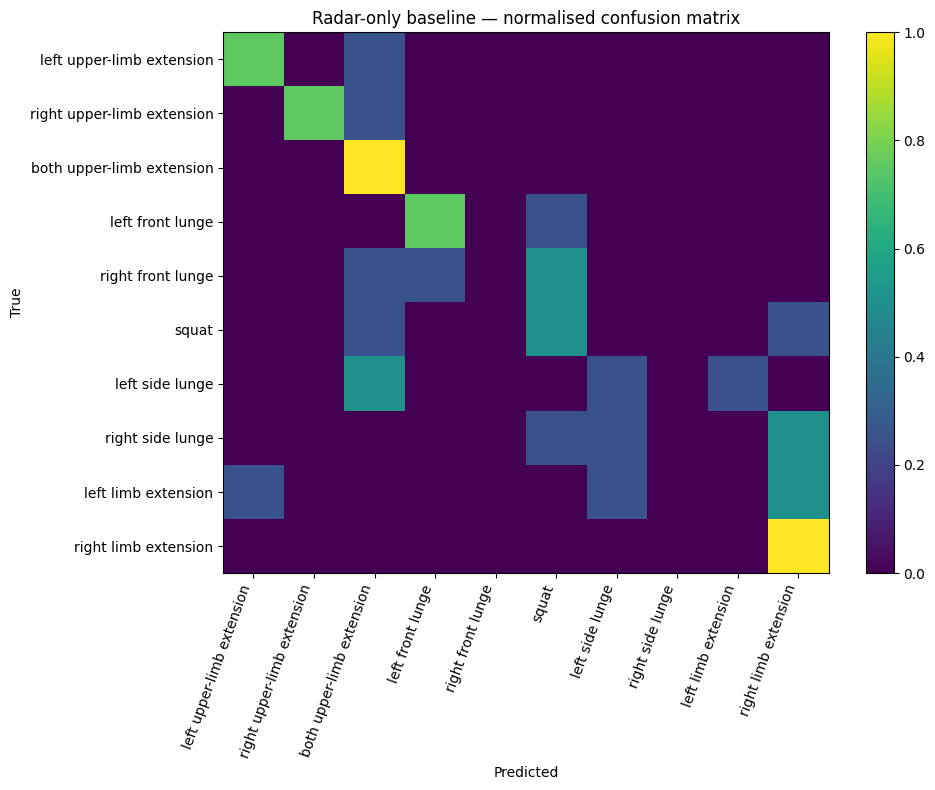


Attention teacher
                            precision    recall  f1-score   support

 left upper-limb extension     0.6667    1.0000    0.8000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     1.0000    0.7500    0.8571         4
          left front lunge     1.0000    1.0000    1.0000         4
         right front lunge     1.0000    1.0000    1.0000         4
                     squat     1.0000    0.5000    0.6667         4
           left side lunge     0.7500    0.7500    0.7500         4
          right side lunge     0.5000    0.5000    0.5000         4
       left limb extension     0.8000    1.0000    0.8889         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.8500        40
                 macro avg     0.8717    0.8500    0.8463        40
              weighted avg     0.8717    0.8500    0.8463        40



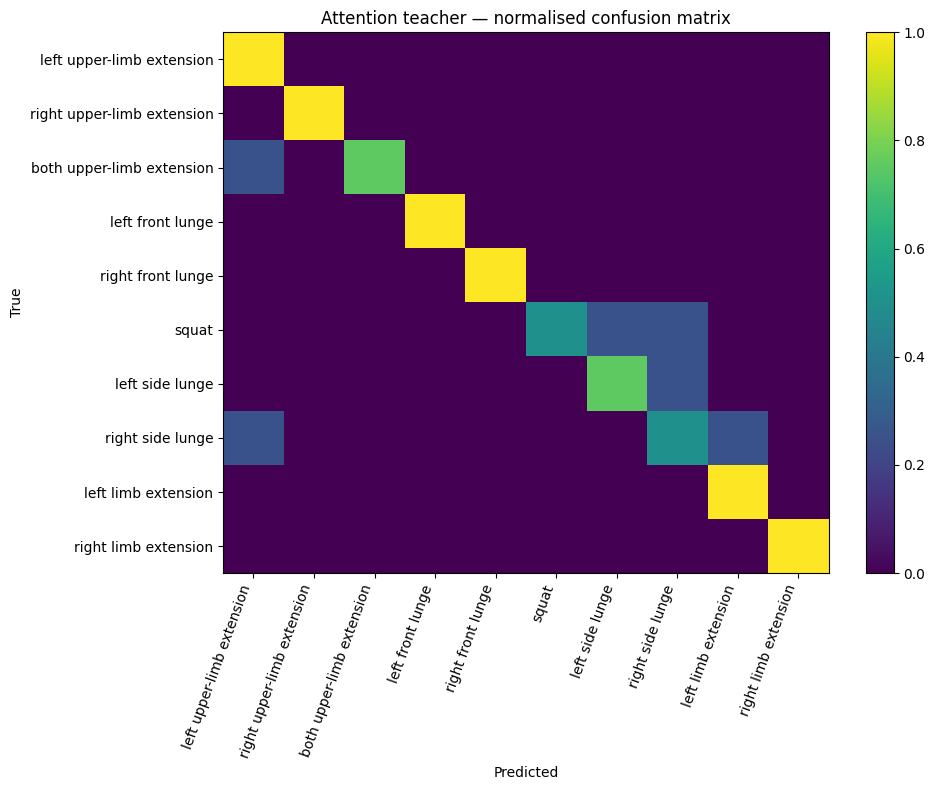


Distilled radar student
                            precision    recall  f1-score   support

 left upper-limb extension     0.6667    1.0000    0.8000         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.5000    0.7500    0.6000         4
          left front lunge     1.0000    0.7500    0.8571         4
         right front lunge     1.0000    0.2500    0.4000         4
                     squat     0.3333    0.2500    0.2857         4
           left side lunge     1.0000    0.2500    0.4000         4
          right side lunge     0.6667    0.5000    0.5714         4
       left limb extension     0.4444    1.0000    0.6154         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.6750        40
                 macro avg     0.7611    0.6750    0.6530        40
              weighted avg     0.7611    0.6750    0.6530        40



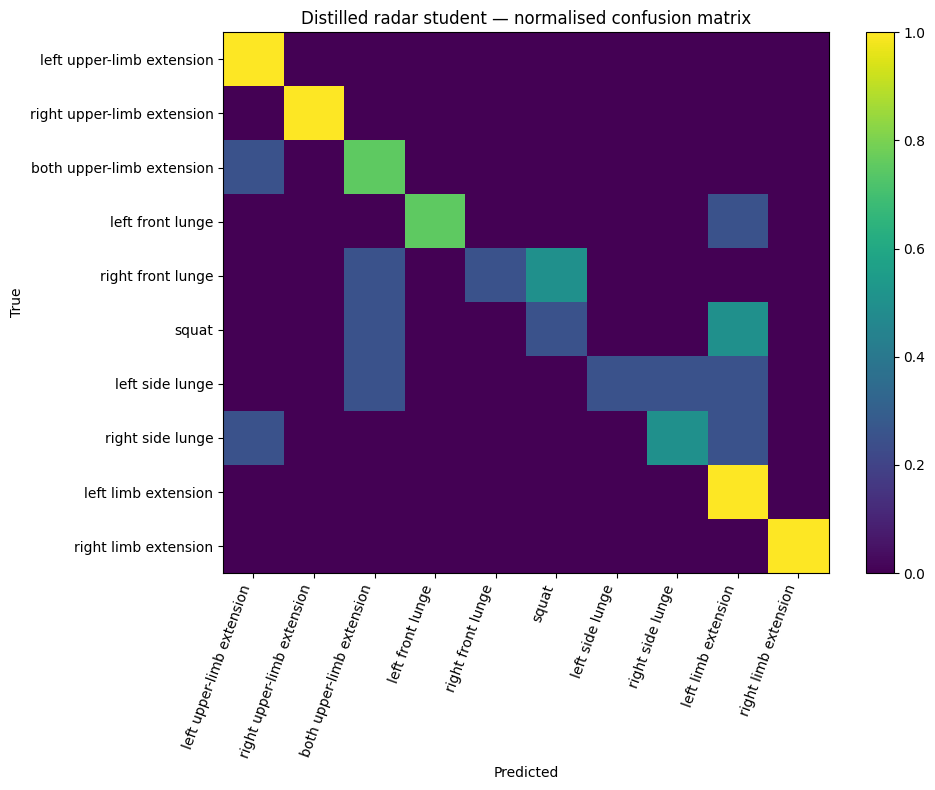

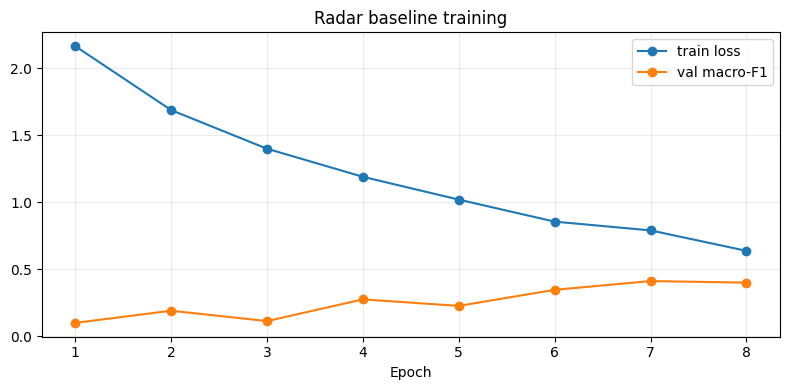

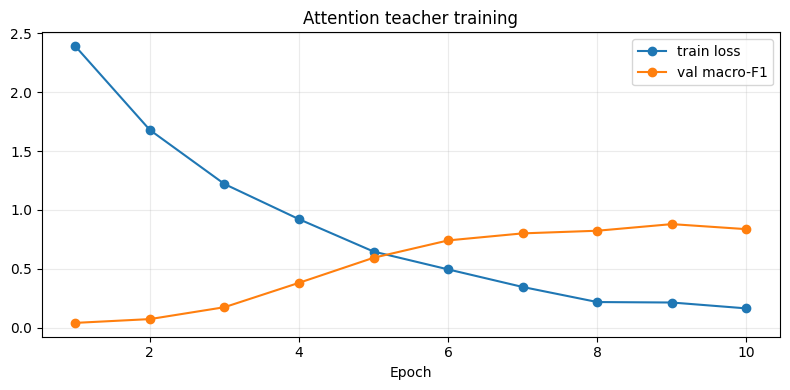

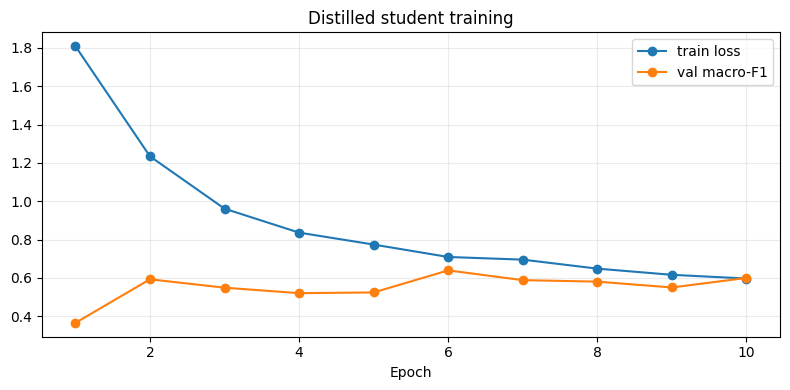

In [21]:
def safe_filename(name):
    return normalise_text(name).replace(" ", "_")

def save_prediction_table(name, pred):
    frame = pd.DataFrame({
        "sample_id": pred["sample_ids"],
        "subject": pred["subjects"],
        "true_id": pred["y_true"],
        "pred_id": pred["y_pred"],
        "true_label": [CLASS_NAMES[i] for i in pred["y_true"]],
        "pred_label": [CLASS_NAMES[i] for i in pred["y_pred"]],
    })
    for i, class_name in enumerate(CLASS_NAMES):
        frame[f"prob_{i:02d}_{safe_filename(class_name)}"] = pred["probs"][:, i]
    frame.to_csv(Path(cfg.WORK_DIR) / f"predictions_{safe_filename(name)}.csv", index=False)
    return frame

def plot_confusion(name, pred, normalise=True):
    cm = confusion_matrix(
        pred["y_true"], pred["y_pred"],
        labels=list(range(NUM_CLASSES)),
        normalize="true" if normalise else None
    )
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, aspect="auto")
    ax.set_title(f"{name} — {'normalised ' if normalise else ''}confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=70, ha="right")
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(
        Path(cfg.WORK_DIR) / f"confusion_{safe_filename(name)}.png",
        dpi=180, bbox_inches="tight"
    )
    plt.show()

for name, pred in predictions.items():
    print("\n" + "=" * 80)
    print(name)
    print(classification_report(
        pred["y_true"], pred["y_pred"],
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        digits=4, zero_division=0
    ))
    save_prediction_table(name, pred)
    plot_confusion(name, pred, normalise=True)

def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
    if "val_macro_f1" in history:
        ax.plot(history["epoch"], history["val_macro_f1"], marker="o", label="val macro-F1")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()

plot_history(radar_history, "Radar baseline training")
plot_history(teacher_history, "Attention teacher training")
plot_history(student_history, "Distilled student training")

,accuracy,balanced_accuracy,macro_f1,weighted_f1
condition,,,,
Clean IMU,0.8500,0.8500,0.8463,0.8463
10% frame masking,0.8500,0.8500,0.8463,0.8463
30% frame masking,0.8500,0.8500,0.8463,0.8463
50% frame masking,0.8250,0.8250,0.8183,0.8183
Gaussian noise sigma=0.25,0.8500,0.8500,0.8463,0.8463
Gaussian noise sigma=0.50,0.8500,0.8500,0.8463,0.8463
One-third sensors missing,0.8000,0.8000,0.7873,0.7873
All IMU zero,0.4000,0.4000,0.3306,0.3306


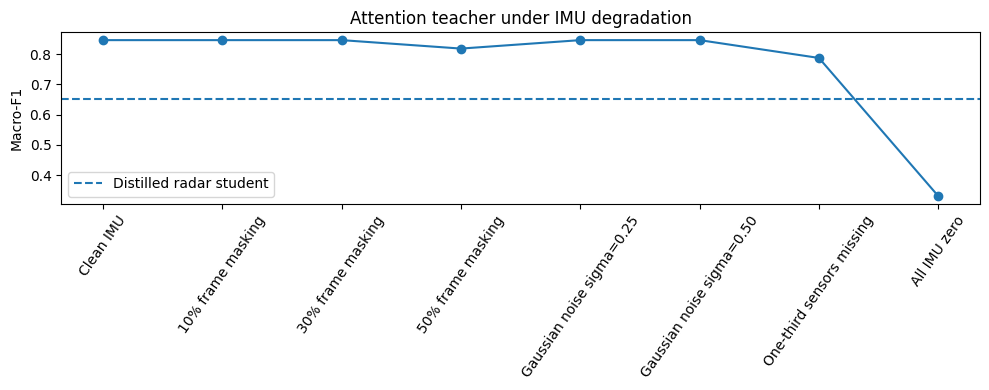

In [22]:
robustness_df = pd.DataFrame()

if cfg.RUN_ROBUSTNESS:
    settings = [
        ("Clean IMU", {"mode": "none", "severity": 0.0}),
        ("10% frame masking", {"mode": "frame_mask", "severity": 0.10}),
        ("30% frame masking", {"mode": "frame_mask", "severity": 0.30}),
        ("50% frame masking", {"mode": "frame_mask", "severity": 0.50}),
        ("Gaussian noise sigma=0.25", {"mode": "gaussian", "severity": 0.25}),
        ("Gaussian noise sigma=0.50", {"mode": "gaussian", "severity": 0.50}),
        ("One-third sensors missing", {"mode": "sensor_mask", "severity": 1/3}),
        ("All IMU zero", {"mode": "zero", "severity": 1.0}),
    ]

    rows = []
    for condition, corruption in settings:
        metrics, _ = evaluate_and_record(
            f"Teacher: {condition}", teacher_model, "attention",
            imu_corruption=corruption
        )
        metrics["condition"] = condition
        rows.append(metrics)

    robustness_df = pd.DataFrame(rows).set_index("condition")
    display(
        robustness_df[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]]
        .style.format("{:.4f}")
    )
    robustness_df.to_csv(Path(cfg.WORK_DIR) / "teacher_imu_robustness.csv")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(robustness_df.index, robustness_df["macro_f1"], marker="o")
    ax.axhline(student_f1, linestyle="--", label="Distilled radar student")
    ax.set_ylabel("Macro-F1")
    ax.set_title("Attention teacher under IMU degradation")
    ax.tick_params(axis="x", rotation=55)
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        Path(cfg.WORK_DIR) / "teacher_imu_robustness.png",
        dpi=180, bbox_inches="tight"
    )
    plt.show()
else:
    print("Robustness section skipped.")

## Optional extended baselines

Set `RUN_EXTENDED_BASELINES=True` to train:

- IMU-only model
- Feature-level concatenation model
- Late fusion by averaging radar-only and IMU-only probabilities

In [26]:
extended_results_df = pd.DataFrame()

if cfg.RUN_EXTENDED_BASELINES:
    imu_model = IMUClassifier(NUM_CLASSES).to(DEVICE)
    imu_history = train_supervised(
        imu_model, train_loader, val_loader,
        "imu", cfg.EXTENDED_EPOCHS, "imu_baseline"
    )

    concat_model = ConcatFusionClassifier(NUM_CLASSES).to(DEVICE)
    concat_history = train_supervised(
        concat_model, train_loader, val_loader,
        "concat", cfg.EXTENDED_EPOCHS, "concat_fusion"
    )

    rows = []

    imu_metrics, imu_pred = evaluate_and_record("IMU-only baseline", imu_model, "imu")
    rows.append(imu_metrics)

    concat_metrics, concat_pred = evaluate_and_record(
        "Feature concatenation", concat_model, "concat"
    )
    rows.append(concat_metrics)

    radar_pred = predictions["Radar-only baseline"]
    assert np.array_equal(radar_pred["sample_ids"], imu_pred["sample_ids"])
    late_probs = 0.5 * radar_pred["probs"] + 0.5 * imu_pred["probs"]
    late_y_pred = late_probs.argmax(axis=1)
    late_metrics = metric_dict(radar_pred["y_true"], late_y_pred)
    late_metrics["model"] = "Late fusion"
    rows.append(late_metrics)

    extended_results_df = pd.DataFrame(rows).set_index("model")
    display(extended_results_df.style.format("{:.4f}"))
    extended_results_df.to_csv(Path(cfg.WORK_DIR) / "extended_test_results.csv")
else:
    print("Extended baselines disabled. Set cfg.RUN_EXTENDED_BASELINES=True to run them.")

imu_baseline | epoch 01/8 | loss=2.1773 | val macro-F1=0.1896 | val balanced-acc=0.2250
imu_baseline | epoch 02/8 | loss=1.2220 | val macro-F1=0.2182 | val balanced-acc=0.2500
imu_baseline | epoch 03/8 | loss=0.7696 | val macro-F1=0.4158 | val balanced-acc=0.4250
imu_baseline | epoch 04/8 | loss=0.5067 | val macro-F1=0.5848 | val balanced-acc=0.6250
imu_baseline | epoch 05/8 | loss=0.3874 | val macro-F1=0.6731 | val balanced-acc=0.7000
imu_baseline | epoch 06/8 | loss=0.2933 | val macro-F1=0.7508 | val balanced-acc=0.7500
imu_baseline | epoch 07/8 | loss=0.2151 | val macro-F1=0.8259 | val balanced-acc=0.8250
imu_baseline | epoch 08/8 | loss=0.1648 | val macro-F1=0.8259 | val balanced-acc=0.8250
concat_fusion | epoch 01/8 | loss=2.3074 | val macro-F1=0.1329 | val balanced-acc=0.1750
concat_fusion | epoch 02/8 | loss=1.9086 | val macro-F1=0.3346 | val balanced-acc=0.4250
concat_fusion | epoch 03/8 | loss=1.5709 | val macro-F1=0.4356 | val balanced-acc=0.5250
concat_fusion | epoch 04/8 | 

,accuracy,balanced_accuracy,macro_f1,weighted_f1
model,,,,
IMU-only baseline,0.8500,0.8500,0.8378,0.8378
Feature concatenation,0.8500,0.8500,0.8459,0.8459
Late fusion,0.9000,0.9000,0.8952,0.8952


In [27]:
teacher_pred = predictions["Attention teacher"]
if teacher_pred["gates"] is not None:
    gates = teacher_pred["gates"]
    gate_summary = pd.DataFrame({
        "class_id": teacher_pred["y_true"],
        "radar_gate_mean": gates.mean(axis=1),
    })
    gate_by_class = gate_summary.groupby("class_id")["radar_gate_mean"].agg(["mean", "std", "count"])
    gate_by_class["class_name"] = [CLASS_NAMES[i] for i in gate_by_class.index]
    display(gate_by_class[["class_name", "mean", "std", "count"]])
    gate_by_class.to_csv(Path(cfg.WORK_DIR) / "attention_gate_by_class.csv")
    print("Gate values near 1 indicate greater radar weighting; values near 0 indicate greater IMU weighting.")

,class_name,mean,std,count
class_id,,,,
0,left upper-limb extension,0.494373,0.000737,4
1,right upper-limb extension,0.493617,0.000762,4
2,both upper-limb extension,0.495187,0.000634,4
3,left front lunge,0.493049,0.000300,4
4,right front lunge,0.496130,0.001484,4
5,squat,0.493980,0.002289,4
6,left side lunge,0.490931,0.002073,4
7,right side lunge,0.493941,0.002874,4
8,left limb extension,0.491997,0.001729,4


Gate values near 1 indicate greater radar weighting; values near 0 indicate greater IMU weighting.


In [28]:
summary = {
    "configuration": asdict(cfg),
    "data_root": str(DATA_ROOT),
    "num_subjects": int(manifest["subject"].nunique()),
    "num_segments": int(len(manifest)),
    "train_subjects": sorted(train_subjects.tolist()),
    "val_subjects": sorted(val_subjects.tolist()),
    "test_subjects": sorted(test_subjects.tolist()),
    "class_names": CLASS_NAMES,
    "core_results": results_df.reset_index().to_dict("records"),
    "feasibility": {
        "teacher_minus_radar_macro_f1": float(teacher_f1 - baseline_f1),
        "student_minus_radar_macro_f1": float(student_f1 - baseline_f1),
        "teacher_stronger_than_radar": bool(teacher_f1 > baseline_f1),
        "student_stronger_than_radar": bool(student_f1 > baseline_f1),
    },
}

with open(Path(cfg.WORK_DIR) / "experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

archive_path = shutil.make_archive(
    str(Path("/kaggle/working") / "mri_kd_pilot_outputs"),
    "zip",
    cfg.WORK_DIR
)

print("Saved output directory:", cfg.WORK_DIR)
print("Output archive:", archive_path)
display(results_df.style.format("{:.4f}"))

Saved output directory: /kaggle/working/mri_kd_pilot
Output archive: /kaggle/working/mri_kd_pilot_outputs.zip


,accuracy,balanced_accuracy,macro_f1,weighted_f1
model,,,,
Attention teacher,0.8500,0.8500,0.8463,0.8463
Distilled radar student,0.6750,0.6750,0.6530,0.6530
Radar-only baseline,0.5000,0.5000,0.4230,0.4230


# Interpretation and next steps

A promising pilot requires:

1. The radar–IMU attention teacher to outperform the ordinary radar-only baseline.
2. The distilled radar-only student to outperform the ordinary radar-only baseline on unseen subjects.
3. The radar-only student to remain unaffected when the teacher/fusion systems degrade under missing or noisy IMU.

Before reporting results:

- Verify `label_mapping_diagnostic.csv`.
- Verify `subject_class_distribution.csv`.
- Repeat the experiment across several fixed subject splits or grouped folds.
- Add hard-label-only, logit-only KD, feature-only KD, and combined-KD ablations.
- Replace proportional temporal mapping with exact timestamp synchronization.
- Report mean, standard deviation, confidence intervals, latency, parameters, and FLOPs.
- Treat the task as rehabilitation-exercise recognition, not clinical diagnosis or recovery assessment.